In [37]:
!pip install pandas numpy scikit-learn mord openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [38]:
file_path = "./Post Methods Sheet.csv"

In [39]:
import os

print(os.getcwd())

for root, dirs, files in os.walk("."):
    if "Post Methods Sheet.csv" in files:
        print(os.path.join(root, "Post Methods Sheet.csv"))

/workspaces/BSAN-Project-2
./Post Methods Sheet.csv


In [40]:
%pip install pandas numpy matplotlib scikit-learn mord openpyxl


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from mord import LogisticAT


# =========================
# 1. LOAD DATA
# =========================

file_path = "./Post Methods Sheet.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill", "RB": "Skill", "FB": "Skill", "WR": "Skill", "TE": "Skill",
    "OT": "OL", "OG": "OL", "G": "OL", "C": "OL", "OC": "OL", "IOL": "OL", "OL": "OL",
    "EDGE": "DL", "DE": "DL", "DT": "DL", "DL": "DL",
    "LB": "LB", "ILB": "LB", "OLB": "LB",
    "CB": "Secondary", "S": "Secondary", "SAF": "Secondary", "DB": "Secondary",
    "K": "Special Teams", "P": "Special Teams", "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE ORDINAL DRAFT TIER
# =========================

def draft_tier(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 96:
        return "Rounds 2-3"
    elif pick <= 160:
        return "Rounds 4-5"
    elif pick <= 262:
        return "Rounds 6-7"
    else:
        return "Undrafted"

df["Draft Tier"] = df["Overall Pick"].apply(draft_tier)

labels_order = [
    "Round 1",
    "Rounds 2-3",
    "Rounds 4-5",
    "Rounds 6-7",
    "Undrafted"
]

tier_to_num = {
    "Round 1": 0,
    "Rounds 2-3": 1,
    "Rounds 4-5": 2,
    "Rounds 6-7": 3,
    "Undrafted": 4
}

num_to_tier = {
    0: "Round 1",
    1: "Rounds 2-3",
    2: "Rounds 4-5",
    3: "Rounds 6-7",
    4: "Undrafted"
}

df["Draft Tier Ordinal"] = df["Draft Tier"].map(tier_to_num)

print("\nDraft Tier Counts:")
print(df["Draft Tier"].value_counts())


# =========================
# 4. FEATURES
# ELO, School, and Arm Length excluded
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]


# =========================
# 5. TRAIN 2023-2025, TEST 2026
# =========================

train_df = df[df["Season"].isin([2023, 2024, 2025])].copy()
test_df = df[df["Season"] == 2026].copy()

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

X_train = train_df[features]
y_train = train_df["Draft Tier Ordinal"]

X_test = test_df[features]
y_test = test_df["Draft Tier Ordinal"]


# =========================
# 6. BUILD MODEL
# =========================

def build_model(feature_list):
    categorical_features = [
        col for col in ["Position", "Position Group", "Conference"]
        if col in feature_list
    ]

    numeric_features = [
        col for col in feature_list if col not in categorical_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("ordinal_model", LogisticAT(alpha=1.0))
        ]
    )

    return model


# =========================
# 7. MANUAL REPORT
# =========================

def print_manual_report(y_true, y_pred, title):
    y_true_labels = pd.Series(y_true).map(num_to_tier)
    y_pred_labels = pd.Series(y_pred).map(num_to_tier)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_labels,
        y_pred_labels,
        labels=labels_order,
        zero_division=0
    )

    print(f"\n{title}")
    print(f"{'Tier':<14}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>12}")

    for label, p, r, f, s in zip(labels_order, precision, recall, f1, support):
        print(f"{label:<14}{p:>12.2f}{r:>12.2f}{f:>12.2f}{s:>12}")

    print("\nAccuracy:", round(accuracy_score(y_true, y_pred), 4))

    ordinal_error = np.mean(np.abs(np.array(y_true) - np.array(y_pred)))
    print("Average Ordinal Error:", round(ordinal_error, 4))


# =========================
# 8. FIT MODEL AND PREDICT 2026
# =========================

overall_model = build_model(features)

overall_model.fit(X_train, y_train)

y_pred = overall_model.predict(X_test)

print_manual_report(
    y_test,
    y_pred,
    "2026 OUT-OF-SAMPLE ORDINAL PREDICTION REPORT"
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# =========================
# 9. FEATURE COEFFICIENTS
# =========================

ordinal_model = overall_model.named_steps["ordinal_model"]
feature_names = overall_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ordinal_model.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

print("\nTop 20 Features by Absolute Coefficient Size:")
print(importance_df.head(20).to_string(index=False))


# =========================
# 10. SAVE 2026 PLAYER PREDICTIONS
# =========================

results = test_df[
    [
        "Season",
        "Player",
        "Position",
        "Position Group",
        "Conference",
        "Overall Pick"
    ]
].copy()

results["Actual Tier Number"] = y_test.values
results["Predicted Tier Number"] = y_pred

results["Actual Tier"] = results["Actual Tier Number"].map(num_to_tier)
results["Predicted Tier"] = results["Predicted Tier Number"].map(num_to_tier)

results["Correct"] = np.where(
    results["Actual Tier Number"] == results["Predicted Tier Number"],
    "Correct",
    "Incorrect"
)

results["Ordinal Error"] = abs(
    results["Actual Tier Number"] - results["Predicted Tier Number"]
)

results.to_csv(
    "2026_out_of_sample_ordinal_predictions.csv",
    index=False
)

importance_df.to_csv(
    "2026_out_of_sample_feature_coefficients.csv",
    index=False
)

print("\nSaved:")
print("2026_out_of_sample_ordinal_predictions.csv")
print("2026_out_of_sample_feature_coefficients.csv")

print("\nSample Predictions:")
print(results.head(25).to_string(index=False))


# =========================
# 11. CHECK COEFFICIENTS AND THRESHOLDS
# =========================

print("\nNumber of coefficients:", len(ordinal_model.coef_))
print("Number of thresholds:", len(ordinal_model.theta_))

Dataset shape: (1272, 27)

Draft Tier Counts:
Draft Tier
Undrafted     347
Rounds 6-7    298
Rounds 2-3    252
Rounds 4-5    247
Round 1       128
Name: count, dtype: int64

Training rows: 965
Testing rows: 307

2026 OUT-OF-SAMPLE ORDINAL PREDICTION REPORT
Tier             Precision      Recall    F1-Score     Support
Round 1               0.50        0.38        0.43          32
Rounds 2-3            0.32        0.14        0.20          63
Rounds 4-5            0.23        0.33        0.27          61
Rounds 6-7            0.26        0.53        0.35          68
Undrafted             0.37        0.12        0.18          83

Accuracy: 0.2834
Average Ordinal Error: 1.0651

Confusion Matrix:
[[12  8  4  8  0]
 [ 5  9 19 27  3]
 [ 5  3 20 25  8]
 [ 1  4 21 36  6]
 [ 1  4 24 44 10]]

Top 20 Features by Absolute Coefficient Size:
                          Feature  Coefficient
              num__National Award    -2.507714
      num__40-Yard Dash (seconds)     0.692299
                 ca

In [42]:
y_prob = overall_model.predict_proba(X_test)

In [43]:
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "legend.title_fontsize": 14
})

In [44]:
pip install pandas numpy matplotlib scikit-learn mord


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Dataset shape: (1272, 27)

Draft Tier Counts:
Draft Tier
Undrafted     347
Rounds 6-7    298
Rounds 2-3    252
Rounds 4-5    247
Round 1       128
Name: count, dtype: int64

Training rows: 965
Testing rows: 307

2026 OUT-OF-SAMPLE ORDINAL PREDICTION REPORT
Tier             Precision      Recall    F1-Score     Support
Round 1               0.52        0.34        0.42          32
Rounds 2-3            0.32        0.17        0.23          63
Rounds 4-5            0.24        0.38        0.30          61
Rounds 6-7            0.20        0.35        0.25          68
Undrafted             0.31        0.13        0.18          83

Accuracy: 0.2606
Average Ordinal Error: 1.0782

Confusion Matrix:
[[11  9  5  6  1]
 [ 4 11 20 24  4]
 [ 4  4 23 21  9]
 [ 1  4 28 24 11]
 [ 1  6 18 47 11]]

Top 20 Features by Absolute Coefficient Size:
                          Feature  Coefficient  Absolute Coefficient Size
              num__National Award       -2.626                      2.626
      num__4

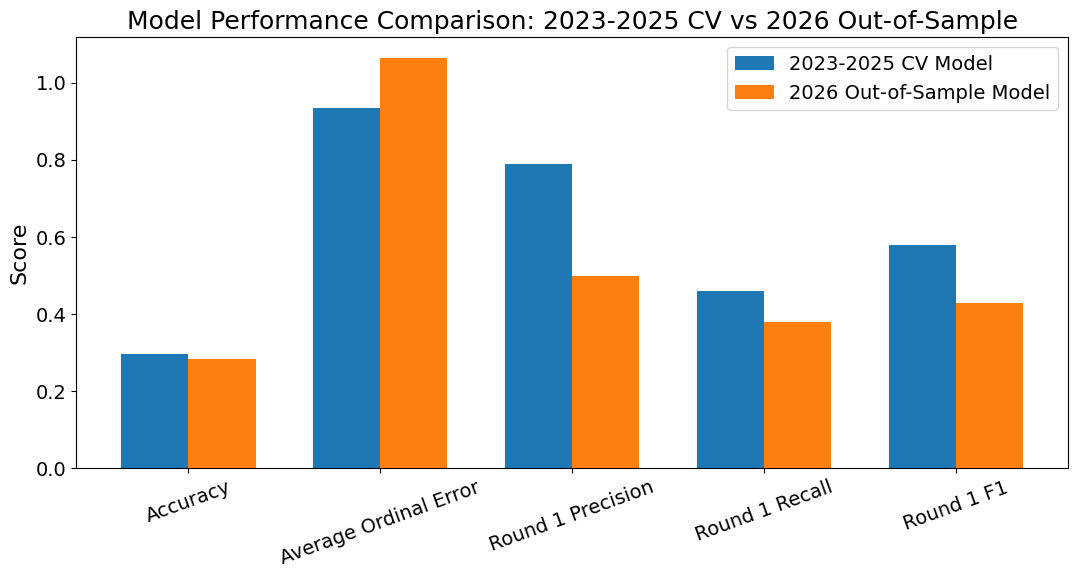

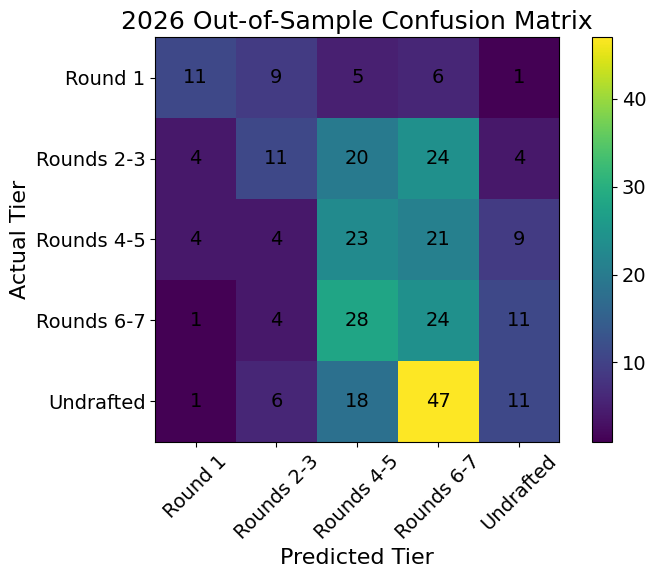

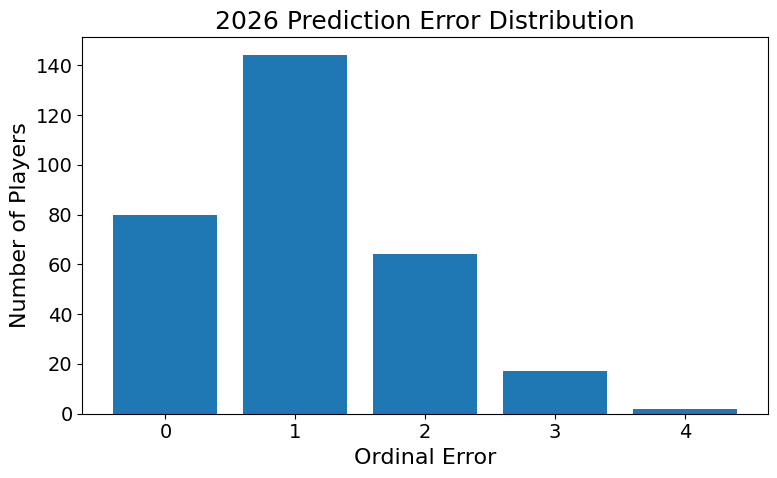

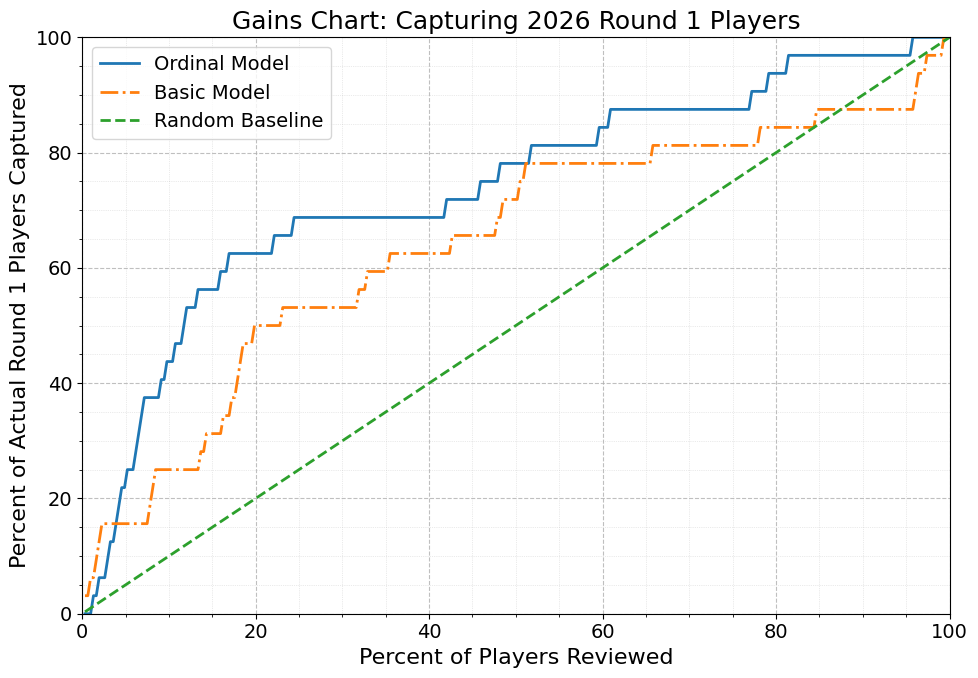

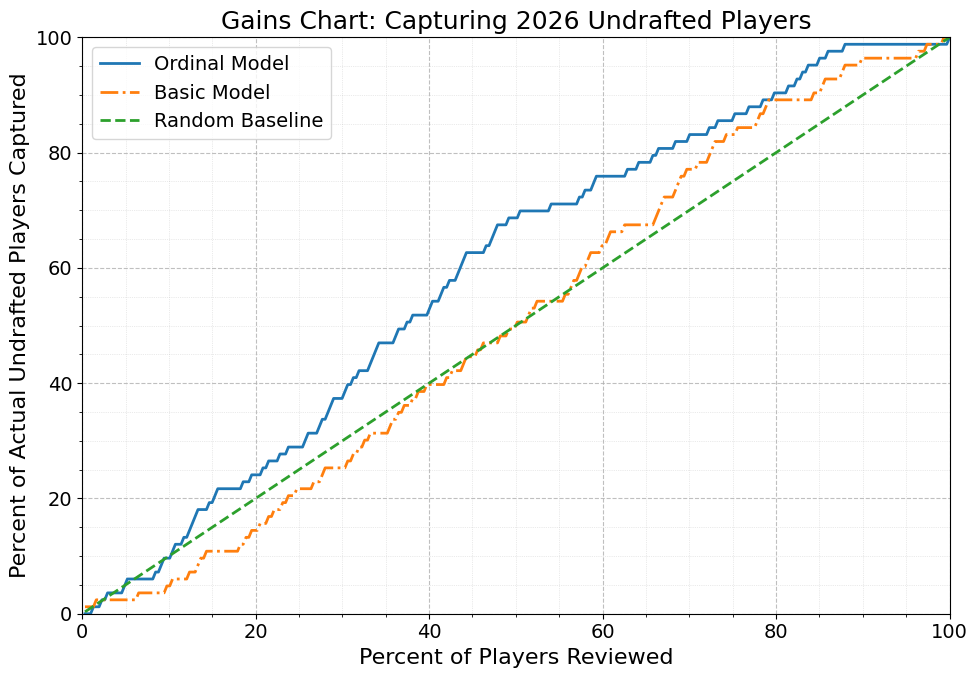


Top 40 Players by Round 1 Probability:
           Player Position Actual Tier Predicted Tier  Prob Round 1
     Joey Aguilar       QB   Undrafted        Round 1      0.806922
   Malik Muhammad       CB  Rounds 4-5        Round 1      0.797467
      Eli Stowers       TE  Rounds 2-3        Round 1      0.795165
     Sonny Styles       LB     Round 1        Round 1      0.788379
     Jermod McCoy       CB  Rounds 4-5        Round 1      0.758651
    Kadyn Proctor       OT     Round 1        Round 1      0.732529
      Red Murdock       LB  Rounds 6-7        Round 1      0.723772
      Carson Beck       QB  Rounds 2-3        Round 1      0.710664
  Francis Mauigoa       OT     Round 1        Round 1      0.695351
 Dillon Thieneman      SAF     Round 1        Round 1      0.659603
       LT Overton       DL  Rounds 4-5        Round 1      0.658936
     Spencer Fano       OT     Round 1        Round 1      0.642399
     David Bailey     EDGE     Round 1        Round 1      0.641023
   Jerem

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

from mord import LogisticAT


# =========================
# 1. LOAD DATA
# =========================

file_path = "./Post Methods Sheet.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)


# =========================
# 2. CREATE POSITION GROUPS
# =========================

position_map = {
    "QB": "Skill", "RB": "Skill", "FB": "Skill", "WR": "Skill", "TE": "Skill",
    "OT": "OL", "OG": "OL", "G": "OL", "C": "OL", "OC": "OL", "IOL": "OL", "OL": "OL",
    "EDGE": "DL", "DE": "DL", "DT": "DL", "DL": "DL",
    "LB": "LB", "ILB": "LB", "OLB": "LB",
    "CB": "Secondary", "S": "Secondary", "SAF": "Secondary", "DB": "Secondary",
    "K": "Special Teams", "P": "Special Teams", "LS": "Special Teams"
}

df["Position Group"] = df["Position"].map(position_map).fillna(df["Position"])


# =========================
# 3. CREATE DRAFT TIER
# =========================

def draft_tier(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 96:
        return "Rounds 2-3"
    elif pick <= 160:
        return "Rounds 4-5"
    elif pick <= 262:
        return "Rounds 6-7"
    else:
        return "Undrafted"


df["Draft Tier"] = df["Overall Pick"].apply(draft_tier)

labels_order = [
    "Round 1",
    "Rounds 2-3",
    "Rounds 4-5",
    "Rounds 6-7",
    "Undrafted"
]

tier_to_num = {
    "Round 1": 0,
    "Rounds 2-3": 1,
    "Rounds 4-5": 2,
    "Rounds 6-7": 3,
    "Undrafted": 4
}

num_to_tier = {
    0: "Round 1",
    1: "Rounds 2-3",
    2: "Rounds 4-5",
    3: "Rounds 6-7",
    4: "Undrafted"
}

df["Draft Tier Ordinal"] = df["Draft Tier"].map(tier_to_num)

print("\nDraft Tier Counts:")
print(df["Draft Tier"].value_counts())


# =========================
# 4. FEATURES
# =========================

features = [
    "Season",
    "Position",
    "Position Group",
    "Conference",
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "FPI",
    "Efficiencies Overall",
    "CFP Appearance",
    "National Award"
]

# Simple comparison model used for gains charts
basic_features = [
    "Season",
    "Position",
    "Conference",
    "CFP Appearance"
]


# =========================
# 5. TRAIN 2023-2025, TEST 2026
# =========================

train_df = df[df["Season"].isin([2023, 2024, 2025])].copy()
test_df = df[df["Season"] == 2026].copy()

print("\nTraining rows:", len(train_df))
print("Testing rows:", len(test_df))

X_train = train_df[features]
y_train = train_df["Draft Tier Ordinal"]

X_test = test_df[features]
y_test = test_df["Draft Tier Ordinal"]


# =========================
# 6. BUILD MODEL
# =========================

def build_model(feature_list):
    categorical_features = [
        col for col in ["Position", "Position Group", "Conference"]
        if col in feature_list
    ]

    numeric_features = [
        col for col in feature_list
        if col not in categorical_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
            ("num", "passthrough", numeric_features)
        ]
    )

    model = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("ordinal_model", LogisticAT(alpha=1.0))
        ]
    )

    return model


# =========================
# 7. REPORT FUNCTION
# =========================

def print_manual_report(y_true, y_pred, title):
    y_true_labels = pd.Series(y_true).map(num_to_tier)
    y_pred_labels = pd.Series(y_pred).map(num_to_tier)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true_labels,
        y_pred_labels,
        labels=labels_order,
        zero_division=0
    )

    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)

    print(f"{'Tier':<14}{'Precision':>12}{'Recall':>12}{'F1-Score':>12}{'Support':>12}")

    for label, p, r, f, s in zip(labels_order, precision, recall, f1, support):
        print(f"{label:<14}{p:>12.2f}{r:>12.2f}{f:>12.2f}{s:>12}")

    accuracy = accuracy_score(y_true, y_pred)
    ordinal_error = np.mean(np.abs(np.array(y_true) - np.array(y_pred)))

    print("\nAccuracy:", round(accuracy, 4))
    print("Average Ordinal Error:", round(ordinal_error, 4))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


# =========================
# 8. FIT ORDINAL MODEL AND PREDICT 2026
# =========================

overall_model = build_model(features)
overall_model.fit(X_train, y_train)

y_pred = overall_model.predict(X_test)
y_prob = overall_model.predict_proba(X_test)

print_manual_report(
    y_test,
    y_pred,
    "2026 OUT-OF-SAMPLE ORDINAL PREDICTION REPORT"
)


# =========================
# 9. FIT BASIC MODEL FOR GAINS CHART COMPARISON
# =========================

X_train_basic = train_df[basic_features]
X_test_basic = test_df[basic_features]

basic_model = build_model(basic_features)
basic_model.fit(X_train_basic, y_train)

basic_y_prob = basic_model.predict_proba(X_test_basic)

basic_prob_df = pd.DataFrame(
    basic_y_prob,
    columns=[
        "Basic Prob Round 1",
        "Basic Prob Rounds 2-3",
        "Basic Prob Rounds 4-5",
        "Basic Prob Rounds 6-7",
        "Basic Prob Undrafted"
    ]
)


# =========================
# 10. FEATURE COEFFICIENTS
# =========================

ordinal_model = overall_model.named_steps["ordinal_model"]
feature_names = overall_model.named_steps["preprocessor"].get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": ordinal_model.coef_
})

importance_df["Absolute Coefficient Size"] = (
    importance_df["Coefficient"].abs().round(3)
)

importance_df["Coefficient"] = (
    importance_df["Coefficient"].round(3)
)

importance_df = importance_df.sort_values(
    by="Absolute Coefficient Size",
    ascending=False
)

print("\nTop 20 Features by Absolute Coefficient Size:")
print(importance_df.head(20).to_string(index=False))


# =========================
# 11. CREATE RESULTS DATAFRAME
# =========================

results = test_df[
    [
        "Season",
        "Player",
        "Position",
        "Position Group",
        "Conference",
        "Overall Pick"
    ]
].copy().reset_index(drop=True)

results["Actual Tier Number"] = y_test.values
results["Predicted Tier Number"] = y_pred

results["Actual Tier"] = results["Actual Tier Number"].map(num_to_tier)
results["Predicted Tier"] = results["Predicted Tier Number"].map(num_to_tier)

results["Correct"] = np.where(
    results["Actual Tier Number"] == results["Predicted Tier Number"],
    "Correct",
    "Incorrect"
)

results["Ordinal Error"] = abs(
    results["Actual Tier Number"] - results["Predicted Tier Number"]
)


# =========================
# 12. ADD PREDICTED PROBABILITIES
# =========================

prob_df = pd.DataFrame(
    y_prob,
    columns=[
        "Prob Round 1",
        "Prob Rounds 2-3",
        "Prob Rounds 4-5",
        "Prob Rounds 6-7",
        "Prob Undrafted"
    ]
)

results = pd.concat(
    [results, prob_df, basic_prob_df],
    axis=1
)

results = results.loc[:, ~results.columns.duplicated()]


# =========================
# 13. SAVE BASE OUTPUTS
# =========================

results.to_csv(
    "2026_out_of_sample_predictions_with_probabilities.csv",
    index=False
)

importance_df.to_csv(
    "2026_out_of_sample_feature_coefficients.csv",
    index=False
)

print("\nSaved:")
print("2026_out_of_sample_predictions_with_probabilities.csv")
print("2026_out_of_sample_feature_coefficients.csv")


# =========================
# 14. METRIC COMPARISON CHART
# =========================

metrics_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Average Ordinal Error",
        "Round 1 Precision",
        "Round 1 Recall",
        "Round 1 F1"
    ],
    "2023-2025 CV Model": [
        0.2975,
        0.9339,
        0.79,
        0.46,
        0.58
    ],
    "2026 Out-of-Sample Model": [
        0.2834,
        1.0651,
        0.50,
        0.38,
        0.43
    ]
})

x = np.arange(len(metrics_df["Metric"]))
width = 0.35

plt.figure(figsize=(11, 6))

plt.bar(
    x - width / 2,
    metrics_df["2023-2025 CV Model"],
    width,
    label="2023-2025 CV Model"
)

plt.bar(
    x + width / 2,
    metrics_df["2026 Out-of-Sample Model"],
    width,
    label="2026 Out-of-Sample Model"
)

plt.xticks(x, metrics_df["Metric"], rotation=20)
plt.ylabel("Score")
plt.title("Model Performance Comparison: 2023-2025 CV vs 2026 Out-of-Sample")
plt.legend()
plt.tight_layout()

plt.savefig(
    "Metric_Comparison_Chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 15. CONFUSION MATRIX VISUAL
# =========================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.title("2026 Out-of-Sample Confusion Matrix")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")

plt.xticks(np.arange(len(labels_order)), labels_order, rotation=45)
plt.yticks(np.arange(len(labels_order)), labels_order)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()

plt.savefig(
    "2026_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 16. ORDINAL ERROR DISTRIBUTION
# =========================

error_counts = results["Ordinal Error"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    error_counts.index.astype(str),
    error_counts.values
)

plt.xlabel("Ordinal Error")
plt.ylabel("Number of Players")
plt.title("2026 Prediction Error Distribution")
plt.tight_layout()

plt.savefig(
    "2026_Ordinal_Error_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 17. GAINS CHART FUNCTION WITH BASIC MODEL
# =========================

def plot_gains_chart(
    results_df,
    target_tier,
    probability_column,
    basic_probability_column,
    title,
    filename
):

    temp = results_df.copy()
    temp = temp.loc[:, ~temp.columns.duplicated()]

    temp["Actual Target"] = np.where(
        temp["Actual Tier"] == target_tier,
        1,
        0
    )

    total_targets = temp["Actual Target"].sum()

    if total_targets == 0:
        print(f"No actual {target_tier} players found.")
        return None

    # Ordinal model ranking
    ordinal_temp = temp.sort_values(
        by=probability_column,
        ascending=False
    ).reset_index(drop=True)

    ordinal_temp["Cumulative Targets Captured"] = (
        ordinal_temp["Actual Target"].cumsum()
    )

    ordinal_temp["Percent of Players Reviewed"] = (
        np.arange(1, len(ordinal_temp) + 1) / len(ordinal_temp)
    ) * 100

    ordinal_temp["Percent of Actual Targets Captured"] = (
        ordinal_temp["Cumulative Targets Captured"] / total_targets
    ) * 100

    # Basic model ranking
    basic_temp = temp.sort_values(
        by=basic_probability_column,
        ascending=False
    ).reset_index(drop=True)

    basic_temp["Cumulative Targets Captured"] = (
        basic_temp["Actual Target"].cumsum()
    )

    basic_temp["Percent of Players Reviewed"] = (
        np.arange(1, len(basic_temp) + 1) / len(basic_temp)
    ) * 100

    basic_temp["Percent of Actual Targets Captured"] = (
        basic_temp["Cumulative Targets Captured"] / total_targets
    ) * 100

    plt.figure(figsize=(10, 7))

    plt.plot(
        ordinal_temp["Percent of Players Reviewed"],
        ordinal_temp["Percent of Actual Targets Captured"],
        linewidth=2,
        label="Ordinal Model"
    )

    plt.plot(
        basic_temp["Percent of Players Reviewed"],
        basic_temp["Percent of Actual Targets Captured"],
        linestyle="-.",
        linewidth=2,
        label="Basic Model"
    )

    plt.plot(
        ordinal_temp["Percent of Players Reviewed"],
        ordinal_temp["Percent of Players Reviewed"],
        linestyle="--",
        linewidth=2,
        label="Random Baseline"
    )

    plt.xlabel("Percent of Players Reviewed")
    plt.ylabel(f"Percent of Actual {target_tier} Players Captured")
    plt.title(title)

    plt.grid(True, which="major", linestyle="--", linewidth=0.8, alpha=0.8)
    plt.minorticks_on()
    plt.grid(True, which="minor", linestyle=":", linewidth=0.5, alpha=0.5)

    plt.xlim(0, 100)
    plt.ylim(0, 100)

    plt.legend()
    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()

    return ordinal_temp


# =========================
# 18. ROUND 1 GAINS CHART
# =========================

round1_gains = plot_gains_chart(
    results_df=results,
    target_tier="Round 1",
    probability_column="Prob Round 1",
    basic_probability_column="Basic Prob Round 1",
    title="Gains Chart: Capturing 2026 Round 1 Players",
    filename="2026_Round1_Gains_Chart.png"
)

if round1_gains is not None:
    round1_gains.to_csv(
        "2026_round1_gains_chart_data.csv",
        index=False
    )


# =========================
# 19. UNDRAFTED GAINS CHART
# =========================

undrafted_gains = plot_gains_chart(
    results_df=results,
    target_tier="Undrafted",
    probability_column="Prob Undrafted",
    basic_probability_column="Basic Prob Undrafted",
    title="Gains Chart: Capturing 2026 Undrafted Players",
    filename="2026_Undrafted_Gains_Chart.png"
)

if undrafted_gains is not None:
    undrafted_gains.to_csv(
        "2026_undrafted_gains_chart_data.csv",
        index=False
    )


# =========================
# 20. TOP-RANKED ROUND 1 PROSPECTS
# =========================

top_round1 = results.sort_values(
    by="Prob Round 1",
    ascending=False
).head(40)

print("\nTop 40 Players by Round 1 Probability:")
print(top_round1[
    [
        "Player",
        "Position",
        "Actual Tier",
        "Predicted Tier",
        "Prob Round 1"
    ]
].to_string(index=False))


# =========================
# 21. TOP-RANKED UNDRAFTED PROSPECTS
# =========================

top_undrafted = results.sort_values(
    by="Prob Undrafted",
    ascending=False
).head(40)

print("\nTop 40 Players by Undrafted Probability:")
print(top_undrafted[
    [
        "Player",
        "Position",
        "Actual Tier",
        "Predicted Tier",
        "Prob Undrafted"
    ]
].to_string(index=False))


# =========================
# 22. FINAL SAVE
# =========================

results.to_csv(
    "2026_final_predictions_visualized.csv",
    index=False
)

print("\nSaved:")
print("2026_final_predictions_visualized.csv")
print("2026_round1_gains_chart_data.csv")
print("2026_undrafted_gains_chart_data.csv")
print("2026_out_of_sample_feature_coefficients.csv")
print("Metric_Comparison_Chart.png")
print("2026_Confusion_Matrix.png")
print("2026_Ordinal_Error_Distribution.png")
print("2026_Round1_Gains_Chart.png")
print("2026_Undrafted_Gains_Chart.png")

In [46]:
# =========================
# DATASET SUMMARY
# =========================

print("\n" + "=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"\nTotal Observations: {len(df):,}")
print(f"Training Observations (2023-2025): {len(train_df):,}")
print(f"Testing Observations (2026): {len(test_df):,}")

print(f"\nTotal Variables Used: {len(features)}")

print("\nVariables Used:")
for i, feature in enumerate(features, start=1):
    print(f"{i}. {feature}")


# =========================
# POSITION BREAKDOWN
# =========================

position_counts = (
    df["Position"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("POSITION BREAKDOWN")
print("=" * 70)

print(position_counts.to_string())

position_counts.to_csv(
    "Position_Breakdown.csv",
    header=["Count"]
)


# =========================
# POSITION GROUP BREAKDOWN
# =========================

position_group_counts = (
    df["Position Group"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("POSITION GROUP BREAKDOWN")
print("=" * 70)

print(position_group_counts.to_string())

position_group_counts.to_csv(
    "Position_Group_Breakdown.csv",
    header=["Count"]
)


# =========================
# CONFERENCE BREAKDOWN
# =========================

conference_counts = (
    df["Conference"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("CONFERENCE BREAKDOWN")
print("=" * 70)

print(conference_counts.to_string())

conference_counts.to_csv(
    "Conference_Breakdown.csv",
    header=["Count"]
)


# =========================
# DRAFT TIER BREAKDOWN
# =========================

draft_tier_counts = (
    df["Draft Tier"]
    .value_counts()
    .reindex(labels_order)
)

print("\n" + "=" * 70)
print("DRAFT TIER BREAKDOWN")
print("=" * 70)

print(draft_tier_counts.to_string())

draft_tier_counts.to_csv(
    "Draft_Tier_Breakdown.csv",
    header=["Count"]
)


# =========================
# TRAIN / TEST BREAKDOWN
# =========================

print("\n" + "=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("\nTraining Seasons:")
print(
    train_df["Season"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nTesting Seasons:")
print(
    test_df["Season"]
    .value_counts()
    .sort_index()
    .to_string()
)

print("\nSaved:")
print("Position_Breakdown.csv")
print("Position_Group_Breakdown.csv")
print("Conference_Breakdown.csv")
print("Draft_Tier_Breakdown.csv")


DATASET SUMMARY

Total Observations: 1,272
Training Observations (2023-2025): 965
Testing Observations (2026): 307

Total Variables Used: 19

Variables Used:
1. Season
2. Position
3. Position Group
4. Conference
5. Height (inches)
6. Weight(lbs)
7. Hand (inches)
8. Wingspan (inches)
9. 40-Yard Dash (seconds)
10. Vertical (inches)
11. Bench (reps)
12. Broad Jump (inches)
13. 3-Cone (seconds)
14. Shuttle (seconds)
15. Combine Participation
16. FPI
17. Efficiencies Overall
18. CFP Appearance
19. National Award

POSITION BREAKDOWN
Position
WR      182
CB      167
EDGE    140
DL      114
RB      107
LB      106
OT      103
IOL      91
TE       84
QB       58
S        46
C        33
SAF      22
K        10
P         7
FB        1
LS        1

POSITION GROUP BREAKDOWN
Position Group
Skill            432
DL               254
Secondary        235
OL               227
LB               106
Special Teams     18

CONFERENCE BREAKDOWN
Conference
SEC                374
Big Ten            284
ACC    

In [47]:
# =========================
# NFL DRAFT ROUND BREAKDOWN
# =========================

def draft_round(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 64:
        return "Round 2"
    elif pick <= 100:
        return "Round 3"
    elif pick <= 138:
        return "Round 4"
    elif pick <= 176:
        return "Round 5"
    elif pick <= 216:
        return "Round 6"
    elif pick <= 262:
        return "Round 7"
    else:
        return "Undrafted"

df["Draft Round"] = df["Overall Pick"].apply(draft_round)

round_order = [
    "Round 1",
    "Round 2",
    "Round 3",
    "Round 4",
    "Round 5",
    "Round 6",
    "Round 7",
    "Undrafted"
]

round_counts = (
    df["Draft Round"]
    .value_counts()
    .reindex(round_order)
)

print("\n" + "=" * 70)
print("DRAFT ROUND BREAKDOWN")
print("=" * 70)

print(round_counts.to_string())

round_counts.to_csv(
    "Draft_Round_Breakdown.csv",
    header=["Count"]
)

print("\nTotal Players:")
print(round_counts.sum())


DRAFT ROUND BREAKDOWN
Draft Round
Round 1      128
Round 2      128
Round 3      140
Round 4      147
Round 5      143
Round 6      124
Round 7      115
Undrafted    347

Total Players:
1272


In [48]:
# =========================
# DESCRIPTIVE STATISTICS
# =========================

numeric_columns = [
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award",
    "Overall Pick"
]

summary_stats = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std Dev": df[numeric_columns].std(),
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max()
})

summary_stats = summary_stats.round(3)

print("\n" + "=" * 90)
print("DESCRIPTIVE STATISTICS")
print("=" * 90)

print(summary_stats)

summary_stats.to_csv(
    "Descriptive_Statistics.csv"
)

print("\nSaved: Descriptive_Statistics.csv")


DESCRIPTIVE STATISTICS
                              Mean   Median  Std Dev  Minimum  Maximum
Height (inches)             74.254   74.375    3.173   65.000  134.750
Weight(lbs)                242.334  231.000   48.205  154.000  374.000
Hand (inches)                9.534    9.500    0.588    7.625   11.625
Wingspan (inches)           77.948   78.030    4.335   54.680  106.550
40-Yard Dash (seconds)       4.717    4.600    0.436    3.940   10.820
Vertical (inches)           34.399   34.500    5.062   20.500   68.290
Bench (reps)                22.139   21.000    8.308    8.000   82.000
Broad Jump (inches)        118.866  120.000   10.571   88.270  188.240
3-Cone (seconds)             7.332    7.170    1.039    4.600   22.540
Shuttle (seconds)            4.480    4.430    0.430    2.810    7.960
Combine Participation        0.794    1.000    0.405    0.000    1.000
FPI                         12.018   11.420    9.594  -19.353   31.487
Efficiencies Overall        69.413   70.238   15.613 

In [49]:
# =========================
# DRAFT RATE BY POSITION
# =========================

position_summary = (
    df.groupby("Position")
    .agg(
        Total_Players=("Player", "count"),
        Drafted_Players=("Overall Pick", lambda x: (x <= 262).sum()),
        Round1_Players=("Overall Pick", lambda x: (x <= 32).sum()),
        Undrafted_Players=("Overall Pick", lambda x: (x > 262).sum())
    )
)

position_summary["Draft_Rate_%"] = (
    position_summary["Drafted_Players"]
    / position_summary["Total_Players"]
    * 100
)

position_summary["Round1_Rate_%"] = (
    position_summary["Round1_Players"]
    / position_summary["Total_Players"]
    * 100
)

position_summary = position_summary.sort_values(
    by="Draft_Rate_%",
    ascending=False
)

position_summary = position_summary.round(2)

print("\n" + "=" * 90)
print("DRAFT RATE BY POSITION")
print("=" * 90)

print(position_summary)

position_summary.to_csv(
    "Draft_Rate_By_Position.csv"
)

print("\nSaved: Draft_Rate_By_Position.csv")


DRAFT RATE BY POSITION
          Total_Players  Drafted_Players  Round1_Players  Undrafted_Players  \
Position                                                                      
OT                  103               82              26                 21   
S                    46               36               1                 10   
SAF                  22               17               2                  5   
DL                  114               88              13                 26   
CB                  167              128              13                 39   
QB                   58               44              13                 14   
C                    33               24               1                  9   
TE                   84               61               5                 23   
EDGE                140              100              21                 40   
IOL                  91               64               4                 27   
WR                  182     

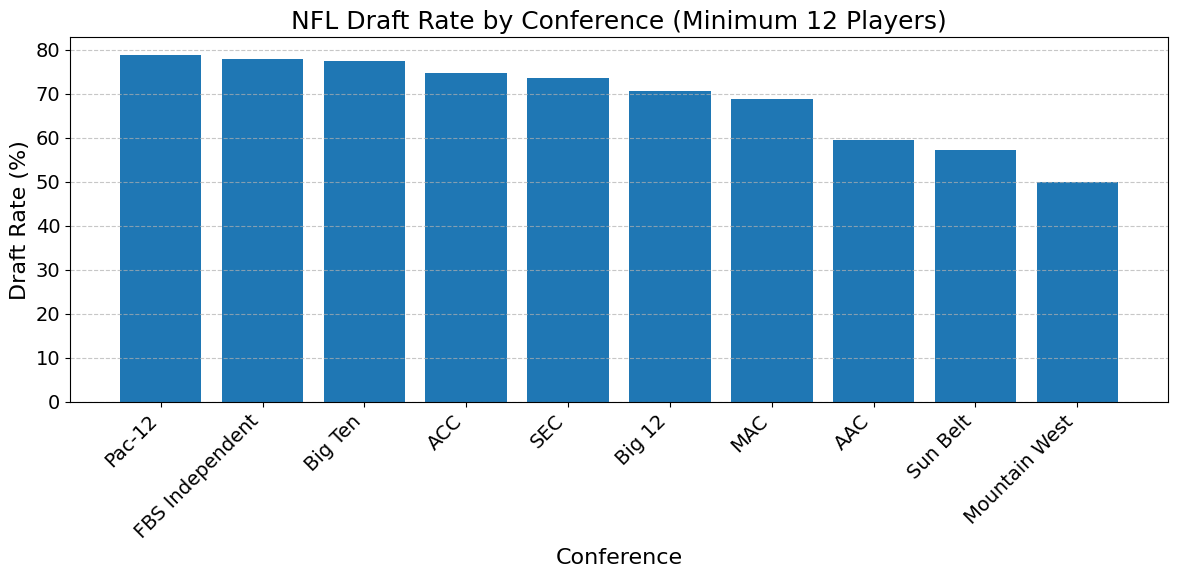

In [50]:
# =========================
# DRAFT RATE BY CONFERENCE BAR CHART
# =========================

conference_summary = (
    df.groupby("Conference")
    .agg(
        Total_Players=("Player", "count"),
        Drafted_Players=("Overall Pick", lambda x: (x <= 262).sum())
    )
)

conference_summary["Draft_Rate_%"] = (
    conference_summary["Drafted_Players"] / conference_summary["Total_Players"] * 100
)

plot_df = conference_summary[
    conference_summary["Total_Players"] >= 12
].sort_values(
    by="Draft_Rate_%",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    plot_df.index,
    plot_df["Draft_Rate_%"]
)

plt.title("NFL Draft Rate by Conference (Minimum 12 Players)")
plt.xlabel("Conference")
plt.ylabel("Draft Rate (%)")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "Draft_Rate_By_Conference.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


DRAFTED VS UNDRAFTED MEAN COMPARISON
Drafted                    Drafted  Undrafted  Difference
Height (inches)             74.222     74.339      -0.117
Weight(lbs)                243.117    240.248       2.869
Hand (inches)                9.552      9.485       0.067
Wingspan (inches)           77.952     77.939       0.013
40-Yard Dash (seconds)       4.707      4.742      -0.035
Vertical (inches)           34.637     33.764       0.873
Bench (reps)                22.236     21.882       0.354
Broad Jump (inches)        119.277    117.771       1.506
3-Cone (seconds)             7.345      7.298       0.047
Shuttle (seconds)            4.478      4.486      -0.008
Combine Participation        0.808      0.758       0.050
FPI                         12.846      9.810       3.035
Efficiencies Overall        70.690     66.010       4.681
Efficiencies Offense        65.882     62.823       3.059
Efficiencies Defense        67.630     62.747       4.882
Efficiencies SpecialTeams   51.608

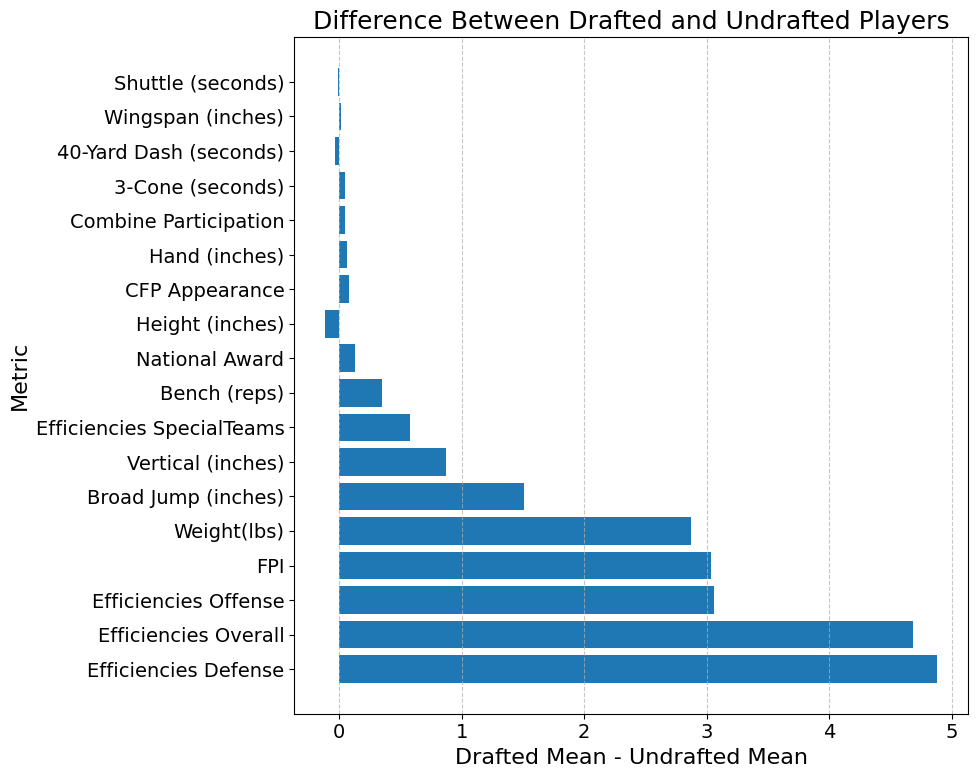


T-TEST RESULTS: DRAFTED VS UNDRAFTED
                 Variable  Drafted Mean  Undrafted Mean  Difference  T-Statistic  P-Value
           National Award        0.1427          0.0144      0.1283       9.7414   0.0000
                      FPI       12.8459          9.8104      3.0354       5.0984   0.0000
     Efficiencies Defense       67.6297         62.7474      4.8823       4.9605   0.0000
     Efficiencies Overall       70.6900         66.0095      4.6805       4.8012   0.0000
           CFP Appearance        0.2335          0.1527      0.0808       3.3901   0.0007
        Vertical (inches)       34.6372         33.7644      0.8728       2.8854   0.0040
     Efficiencies Offense       65.8822         62.8227      3.0595       2.8196   0.0050
      Broad Jump (inches)      119.2772        117.7712      1.5061       2.3321   0.0200
    Combine Participation        0.8076          0.7579      0.0496       1.8784   0.0608
            Hand (inches)        9.5524          9.4851      0

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind


# =========================
# 1. CREATE DRAFTED VARIABLE
# =========================

df["Drafted"] = np.where(
    df["Overall Pick"] <= 262,
    "Drafted",
    "Undrafted"
)


# =========================
# 2. SELECT NUMERIC VARIABLES
# =========================

numeric_columns = [
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "Combine Participation",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]


# =========================
# 3. MEAN COMPARISON TABLE
# =========================

draft_comparison = (
    df.groupby("Drafted")[numeric_columns]
    .mean()
    .T
)

draft_comparison["Difference"] = (
    draft_comparison["Drafted"]
    - draft_comparison["Undrafted"]
)

draft_comparison = draft_comparison.round(3)

print("\n" + "=" * 90)
print("DRAFTED VS UNDRAFTED MEAN COMPARISON")
print("=" * 90)

print(draft_comparison)

draft_comparison.to_csv(
    "Drafted_vs_Undrafted_Mean_Comparison.csv"
)


# =========================
# 4. LARGEST DIFFERENCES
# =========================

largest_differences = (
    draft_comparison
    .reindex(
        draft_comparison["Difference"]
        .abs()
        .sort_values(ascending=False)
        .index
    )
)

print("\n" + "=" * 90)
print("BIGGEST DIFFERENCES BETWEEN DRAFTED AND UNDRAFTED PLAYERS")
print("=" * 90)

print(
    largest_differences[
        ["Drafted", "Undrafted", "Difference"]
    ]
)

largest_differences.to_csv(
    "Drafted_vs_Undrafted_Largest_Differences.csv"
)


# =========================
# 5. DIFFERENCE BAR CHART
# =========================

plot_df = largest_differences.copy()

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df.index,
    plot_df["Difference"]
)

plt.title(
    "Difference Between Drafted and Undrafted Players"
)

plt.xlabel(
    "Drafted Mean - Undrafted Mean"
)

plt.ylabel(
    "Metric"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "Drafted_vs_Undrafted_Differences.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 6. T-TESTS FOR STATISTICAL DIFFERENCES
# =========================

ttest_rows = []

for col in numeric_columns:

    drafted_values = df[df["Drafted"] == "Drafted"][col].dropna()
    undrafted_values = df[df["Drafted"] == "Undrafted"][col].dropna()

    t_stat, p_value = ttest_ind(
        drafted_values,
        undrafted_values,
        equal_var=False
    )

    ttest_rows.append({
        "Variable": col,
        "Drafted Mean": drafted_values.mean(),
        "Undrafted Mean": undrafted_values.mean(),
        "Difference": drafted_values.mean() - undrafted_values.mean(),
        "T-Statistic": t_stat,
        "P-Value": p_value
    })

ttest_results = pd.DataFrame(ttest_rows)

ttest_results = ttest_results.sort_values(
    by="P-Value"
)

ttest_results = ttest_results.round(4)

print("\n" + "=" * 90)
print("T-TEST RESULTS: DRAFTED VS UNDRAFTED")
print("=" * 90)

print(ttest_results.to_string(index=False))

ttest_results.to_csv(
    "Drafted_vs_Undrafted_TTests.csv",
    index=False
)


# =========================
# 7. POSITION BREAKDOWN BY DRAFT STATUS
# =========================

position_draft_status = pd.crosstab(
    df["Position"],
    df["Drafted"]
)

position_draft_status["Total"] = (
    position_draft_status["Drafted"] +
    position_draft_status["Undrafted"]
)

position_draft_status["Draft Rate %"] = (
    position_draft_status["Drafted"]
    / position_draft_status["Total"]
    * 100
)

position_draft_status = position_draft_status.sort_values(
    by="Draft Rate %",
    ascending=False
)

position_draft_status = position_draft_status.round(2)

print("\n" + "=" * 90)
print("DRAFT STATUS BY POSITION")
print("=" * 90)

print(position_draft_status)

position_draft_status.to_csv(
    "Draft_Status_By_Position.csv"
)


# =========================
# 8. CONFERENCE BREAKDOWN BY DRAFT STATUS
# =========================

conference_draft_status = pd.crosstab(
    df["Conference"],
    df["Drafted"]
)

conference_draft_status["Total"] = (
    conference_draft_status["Drafted"] +
    conference_draft_status["Undrafted"]
)

conference_draft_status["Draft Rate %"] = (
    conference_draft_status["Drafted"]
    / conference_draft_status["Total"]
    * 100
)

conference_draft_status = conference_draft_status.sort_values(
    by="Draft Rate %",
    ascending=False
)

conference_draft_status = conference_draft_status.round(2)

print("\n" + "=" * 90)
print("DRAFT STATUS BY CONFERENCE")
print("=" * 90)

print(conference_draft_status)

conference_draft_status.to_csv(
    "Draft_Status_By_Conference.csv"
)


# =========================
# 9. SAVE ALL SUMMARY FILES
# =========================

print("\nSaved:")
print("Drafted_vs_Undrafted_Mean_Comparison.csv")
print("Drafted_vs_Undrafted_Largest_Differences.csv")
print("Drafted_vs_Undrafted_Differences.png")
print("Drafted_vs_Undrafted_TTests.csv")
print("Draft_Status_By_Position.csv")
print("Draft_Status_By_Conference.csv")

In [52]:
position = "WR"   # Change to QB, RB, EDGE, CB, etc.

numeric_columns = [
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]

temp = df[df["Position"] == position].copy()

comparison = (
    temp.groupby("Drafted")[numeric_columns]
    .mean()
    .T
)

comparison["Difference"] = (
    comparison["Drafted"]
    - comparison["Undrafted"]
)

comparison = comparison.round(3)

print(comparison)

Drafted                    Drafted  Undrafted  Difference
Height (inches)             72.592     73.268      -0.676
Weight(lbs)                196.262    198.696      -2.435
Hand (inches)                9.327      9.417      -0.090
Wingspan (inches)           75.982     76.490      -0.508
40-Yard Dash (seconds)       4.450      4.515      -0.066
Vertical (inches)           36.980     36.072       0.908
Bench (reps)                17.865     17.661       0.204
Broad Jump (inches)        125.780    123.848       1.932
3-Cone (seconds)             6.890      6.905      -0.015
Shuttle (seconds)            4.231      4.316      -0.085
FPI                         11.575     10.599       0.976
Efficiencies Overall        68.786     67.515       1.271
Efficiencies Offense        66.855     64.625       2.231
Efficiencies Defense        63.389     63.349       0.040
Efficiencies SpecialTeams   51.621     50.584       1.037
CFP Appearance               0.198      0.161       0.038
National Award

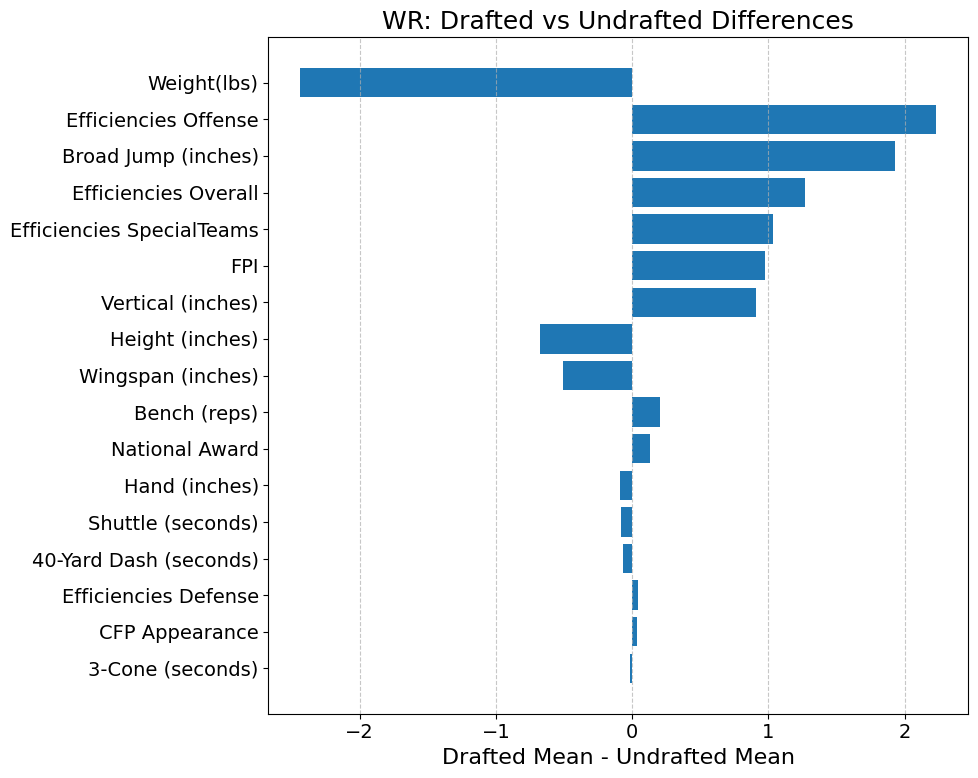

In [53]:
plot_df = comparison.sort_values(
    by="Difference",
    key=abs,
    ascending=True
)

plt.figure(figsize=(10,8))

plt.barh(
    plot_df.index,
    plot_df["Difference"]
)

plt.title(
    f"{position}: Drafted vs Undrafted Differences"
)

plt.xlabel(
    "Drafted Mean - Undrafted Mean"
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()
plt.show()

In [54]:
positions = sorted(df["Position"].dropna().unique())

results = []

for pos in positions:

    temp = df[df["Position"] == pos]

    drafted_count = (temp["Overall Pick"] <= 262).sum()
    undrafted_count = (temp["Overall Pick"] > 262).sum()

    if drafted_count < 5 or undrafted_count < 5:
        continue

    for metric in [
        "40-Yard Dash (seconds)",
        "Vertical (inches)",
        "Broad Jump (inches)",
        "Bench (reps)",
        "FPI",
        "Efficiencies Overall"
    ]:

        drafted_mean = temp.loc[
            temp["Overall Pick"] <= 262,
            metric
        ].mean()

        undrafted_mean = temp.loc[
            temp["Overall Pick"] > 262,
            metric
        ].mean()

        results.append([
            pos,
            metric,
            drafted_mean,
            undrafted_mean,
            drafted_mean - undrafted_mean
        ])

position_results = pd.DataFrame(
    results,
    columns=[
        "Position",
        "Metric",
        "Drafted Mean",
        "Undrafted Mean",
        "Difference"
    ]
)

position_results.to_csv(
    "Position_Level_Differences.csv",
    index=False
)

print(position_results)

   Position                  Metric  Drafted Mean  Undrafted Mean  Difference
0         C  40-Yard Dash (seconds)      5.154167        5.092222    0.061944
1         C       Vertical (inches)     30.604167       30.111111    0.493056
2         C     Broad Jump (inches)    107.250000      106.000000    1.250000
3         C            Bench (reps)     23.791667       25.444444   -1.652778
4         C                     FPI     12.171375       17.992222   -5.820847
..      ...                     ...           ...             ...         ...
73       WR       Vertical (inches)     36.979921       36.072321    0.907599
74       WR     Broad Jump (inches)    125.779921      123.848036    1.931885
75       WR            Bench (reps)     17.865079       17.660714    0.204365
76       WR                     FPI     11.575032       10.598571    0.976460
77       WR    Efficiencies Overall     68.786294       67.515036    1.271258

[78 rows x 5 columns]


In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Create folder for charts
os.makedirs("Position_Charts", exist_ok=True)

numeric_columns = [
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "FPI",
    "Efficiencies Overall",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "CFP Appearance",
    "National Award"
]

positions = sorted(df["Position"].dropna().unique())

for pos in positions:

    temp = df[df["Position"] == pos].copy()

    drafted_count = (temp["Overall Pick"] <= 262).sum()
    undrafted_count = (temp["Overall Pick"] > 262).sum()

    # Skip positions with too few observations
    if drafted_count < 5 or undrafted_count < 5:
        continue

    temp["Drafted"] = np.where(
        temp["Overall Pick"] <= 262,
        "Drafted",
        "Undrafted"
    )

    comparison = (
        temp.groupby("Drafted")[numeric_columns]
        .mean()
        .T
    )

    comparison["Difference"] = (
        comparison["Drafted"]
        - comparison["Undrafted"]
    )

    comparison = comparison.sort_values(
        by="Difference",
        key=abs,
        ascending=True
    )

    plt.figure(figsize=(8,6))

    plt.barh(
        comparison.index,
        comparison["Difference"]
    )

    plt.title(
        f"{pos}: Drafted vs Undrafted Differences"
    )

    plt.xlabel(
        "Drafted Mean - Undrafted Mean"
    )

    plt.grid(
        axis="x",
        linestyle="--",
        alpha=0.7
    )

    plt.tight_layout()

    plt.savefig(
        f"Position_Charts/{pos}_Drafted_vs_Undrafted.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

print("All position charts saved.")

All position charts saved.


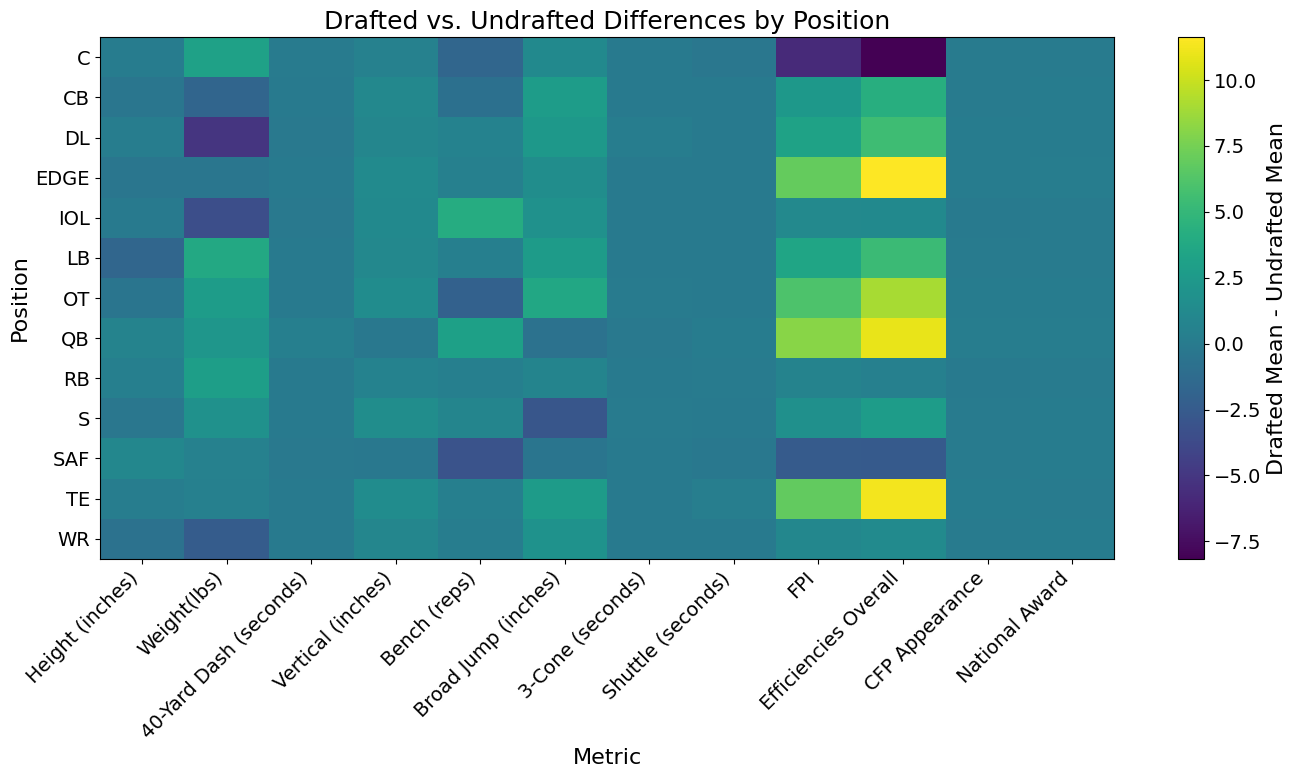

Saved:
Drafted_vs_Undrafted_By_Position_Heatmap.png
Drafted_vs_Undrafted_By_Position_Differences.csv


In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DRAFTED VS UNDRAFTED DIFFERENCES BY POSITION
# ONE COMBINED VISUAL
# =========================

df["Drafted"] = np.where(
    df["Overall Pick"] <= 262,
    "Drafted",
    "Undrafted"
)

metrics = [
    "Height (inches)",
    "Weight(lbs)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "FPI",
    "Efficiencies Overall",
    "CFP Appearance",
    "National Award"
]

positions = sorted(df["Position"].dropna().unique())

rows = []

for pos in positions:
    temp = df[df["Position"] == pos].copy()

    drafted_count = (temp["Drafted"] == "Drafted").sum()
    undrafted_count = (temp["Drafted"] == "Undrafted").sum()

    # Skip positions with too few observations
    if drafted_count < 5 or undrafted_count < 5:
        continue

    row = {"Position": pos}

    for metric in metrics:
        drafted_mean = temp.loc[temp["Drafted"] == "Drafted", metric].mean()
        undrafted_mean = temp.loc[temp["Drafted"] == "Undrafted", metric].mean()

        row[metric] = drafted_mean - undrafted_mean

    rows.append(row)

position_diff = pd.DataFrame(rows).set_index("Position")

# =========================
# HEATMAP
# =========================

plt.figure(figsize=(14, 8))

plt.imshow(
    position_diff,
    aspect="auto"
)

plt.colorbar(label="Drafted Mean - Undrafted Mean")

plt.xticks(
    ticks=np.arange(len(position_diff.columns)),
    labels=position_diff.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(position_diff.index)),
    labels=position_diff.index
)

plt.title("Drafted vs. Undrafted Differences by Position")
plt.xlabel("Metric")
plt.ylabel("Position")

plt.tight_layout()

plt.savefig(
    "Drafted_vs_Undrafted_By_Position_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

position_diff.to_csv(
    "Drafted_vs_Undrafted_By_Position_Differences.csv"
)

print("Saved:")
print("Drafted_vs_Undrafted_By_Position_Heatmap.png")
print("Drafted_vs_Undrafted_By_Position_Differences.csv")

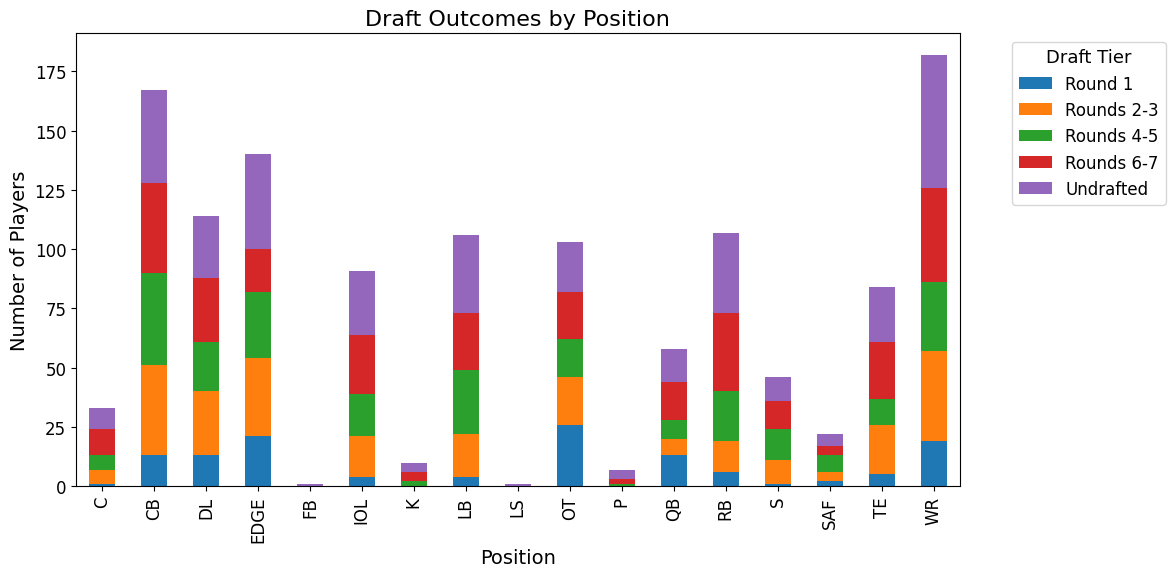

In [57]:
draft_position = pd.crosstab(
    df["Position"],
    df["Draft Tier"]
)

draft_position = draft_position.reindex(
    columns=[
        "Round 1",
        "Rounds 2-3",
        "Rounds 4-5",
        "Rounds 6-7",
        "Undrafted"
    ]
)

draft_position.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Draft Outcomes by Position", fontsize=16)
plt.xlabel("Position", fontsize=14)
plt.ylabel("Number of Players", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.legend(
    title="Draft Tier",
    bbox_to_anchor=(1.05,1),
    fontsize=12,
    title_fontsize=13
)

plt.tight_layout()
plt.show()


Positions Included:
['C', 'CB', 'DL', 'EDGE', 'IOL', 'LB', 'OT', 'QB', 'RB', 'S', 'SAF', 'TE', 'WR']


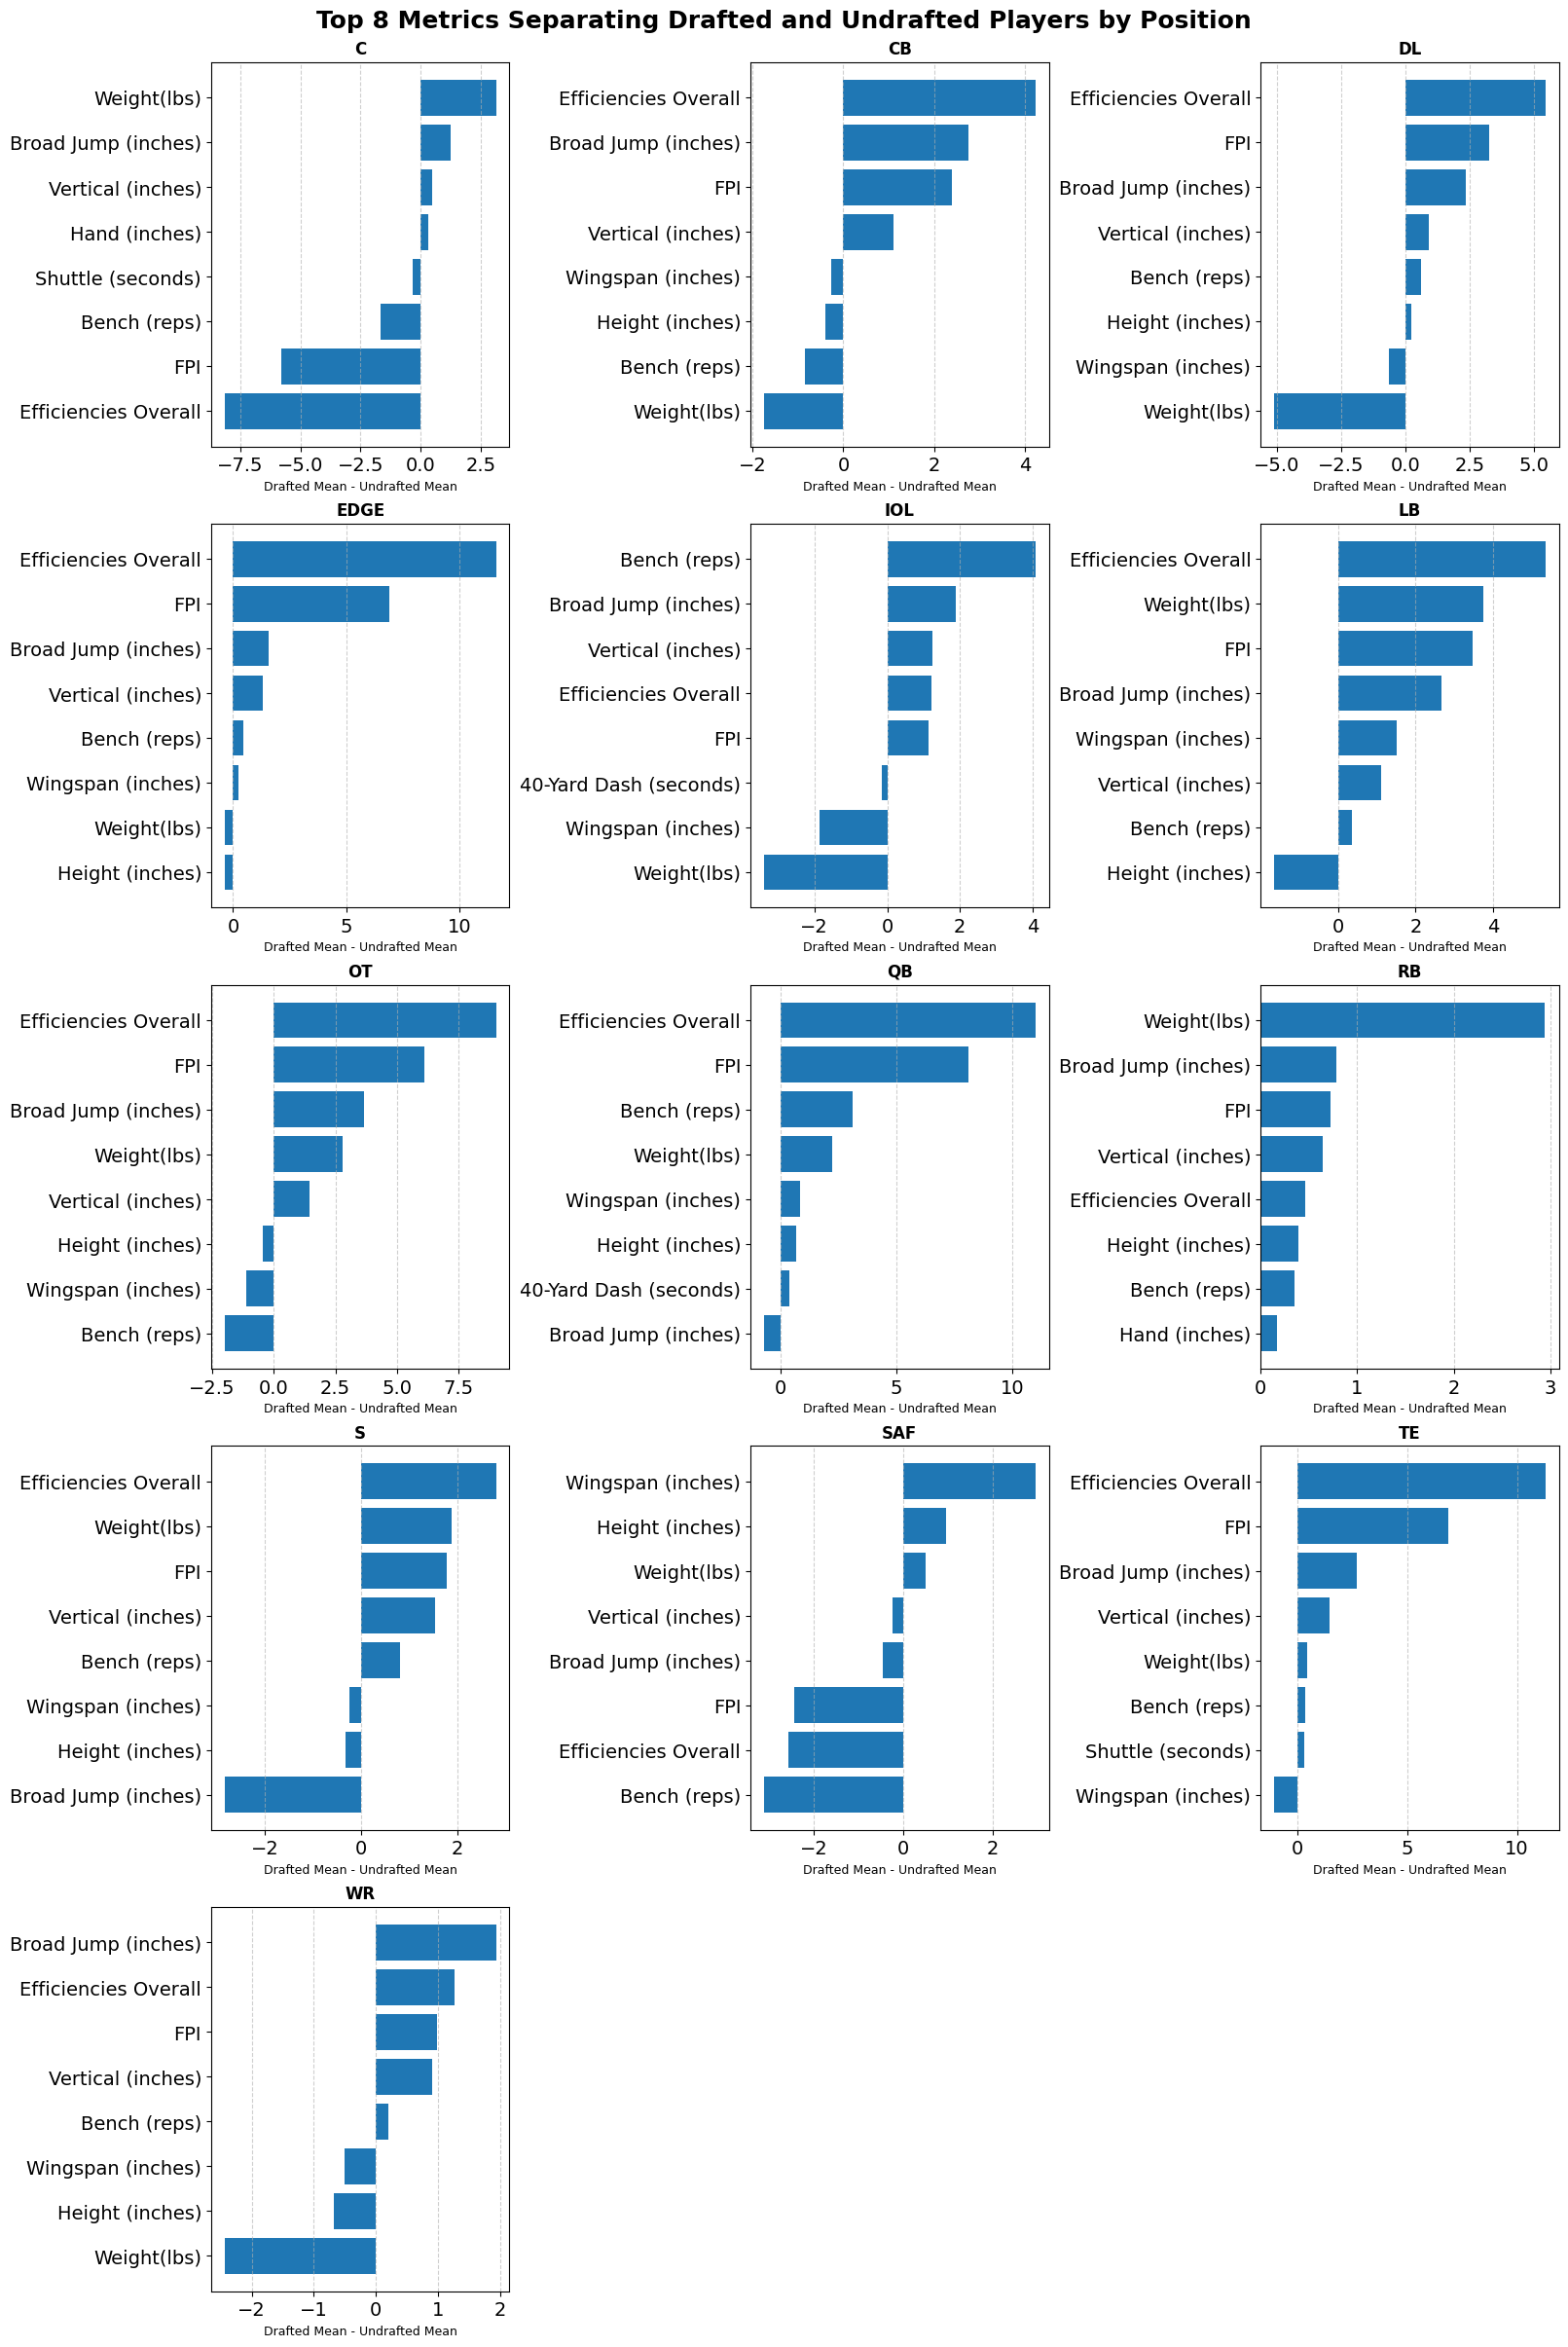


Saved: Top_8_Metrics_By_Position_Drafted_vs_Undrafted.png
Saved: Position_Level_Differences.csv


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# DRAFTED VS UNDRAFTED
# TOP 8 METRICS BY POSITION
# =========================

df["Drafted"] = np.where(
    df["Overall Pick"] <= 262,
    1,
    0
)

# Only Overall Efficiency kept
# Offense, Defense, and Special Teams removed

metrics = [
    "Height (inches)",
    "Weight(lbs)",
    "Hand (inches)",
    "Wingspan (inches)",
    "40-Yard Dash (seconds)",
    "Vertical (inches)",
    "Bench (reps)",
    "Broad Jump (inches)",
    "3-Cone (seconds)",
    "Shuttle (seconds)",
    "FPI",
    "Efficiencies Overall",
    "CFP Appearance",
    "National Award"
]

positions = sorted(
    df["Position"]
    .dropna()
    .unique()
)

valid_positions = []

# =========================
# KEEP ONLY POSITIONS WITH
# AT LEAST 5 DRAFTED AND
# 5 UNDRAFTED PLAYERS
# =========================

for pos in positions:

    temp = df[df["Position"] == pos]

    drafted_count = (
        temp["Drafted"] == 1
    ).sum()

    undrafted_count = (
        temp["Drafted"] == 0
    ).sum()

    if drafted_count >= 5 and undrafted_count >= 5:
        valid_positions.append(pos)

print("\nPositions Included:")
print(valid_positions)

cols = 3
rows = int(
    np.ceil(
        len(valid_positions) / cols
    )
)

# =========================
# CREATE FIGURE
# =========================

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(16, rows * 4.8),
    constrained_layout=True
)

axes = axes.flatten()

# =========================
# BUILD CHART FOR EACH POSITION
# =========================

for i, pos in enumerate(valid_positions):

    temp = df[
        df["Position"] == pos
    ]

    differences = {}

    for metric in metrics:

        drafted_mean = (
            temp.loc[
                temp["Drafted"] == 1,
                metric
            ]
            .mean()
        )

        undrafted_mean = (
            temp.loc[
                temp["Drafted"] == 0,
                metric
            ]
            .mean()
        )

        differences[metric] = (
            drafted_mean
            - undrafted_mean
        )

    diff_df = pd.DataFrame({
        "Metric": differences.keys(),
        "Difference": differences.values()
    })

    # Top 8 strongest differences

    diff_df = diff_df.reindex(
        diff_df["Difference"]
        .abs()
        .sort_values(
            ascending=False
        )
        .index
    ).head(8)

    # Sort for cleaner horizontal bars

    diff_df = diff_df.sort_values(
        by="Difference"
    )

    axes[i].barh(
        diff_df["Metric"],
        diff_df["Difference"]
    )

    axes[i].set_title(
        pos,
        fontsize=12,
        fontweight="bold"
    )

    axes[i].set_xlabel(
        "Drafted Mean - Undrafted Mean",
        fontsize=9
    )

    axes[i].grid(
        axis="x",
        linestyle="--",
        alpha=0.6
    )

# =========================
# REMOVE UNUSED PANELS
# =========================

for j in range(
    i + 1,
    len(axes)
):
    fig.delaxes(
        axes[j]
    )

# =========================
# MAIN TITLE
# =========================

fig.suptitle(
    "Top 8 Metrics Separating Drafted and Undrafted Players by Position",
    fontsize=18,
    fontweight="bold"
)

# =========================
# SAVE OUTPUT
# =========================

plt.savefig(
    "Top_8_Metrics_By_Position_Drafted_vs_Undrafted.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================
# SAVE UNDERLYING DATA
# =========================

all_results = []

for pos in valid_positions:

    temp = df[
        df["Position"] == pos
    ]

    for metric in metrics:

        drafted_mean = (
            temp.loc[
                temp["Drafted"] == 1,
                metric
            ]
            .mean()
        )

        undrafted_mean = (
            temp.loc[
                temp["Drafted"] == 0,
                metric
            ]
            .mean()
        )

        difference = (
            drafted_mean
            - undrafted_mean
        )

        all_results.append([
            pos,
            metric,
            drafted_mean,
            undrafted_mean,
            difference
        ])

results_df = pd.DataFrame(
    all_results,
    columns=[
        "Position",
        "Metric",
        "Drafted Mean",
        "Undrafted Mean",
        "Difference"
    ]
)

results_df.to_csv(
    "Position_Level_Differences.csv",
    index=False
)

print(
    "\nSaved: Top_8_Metrics_By_Position_Drafted_vs_Undrafted.png"
)

print(
    "Saved: Position_Level_Differences.csv"
)


CFP, FPI, AND OVERALL EFFICIENCY BY DRAFT TIER
            Players  CFP_Appearance_Rate  Average_FPI  Median_FPI  \
Draft Tier                                                          
Round 1         128               35.156       17.541      19.976   
Rounds 2-3      252               25.000       13.810      14.234   
Rounds 4-5      247               21.457       11.744      11.793   
Rounds 6-7      298               18.456       10.927      10.676   
Undrafted       347               15.274        9.810       9.315   

            Average_Efficiency_Overall  Median_Efficiency_Overall  
Draft Tier                                                         
Round 1                         77.595                     82.006  
Rounds 2-3                      72.472                     74.986  
Rounds 4-5                      69.008                     71.717  
Rounds 6-7                      67.612                     68.518  
Undrafted                       66.010                     6

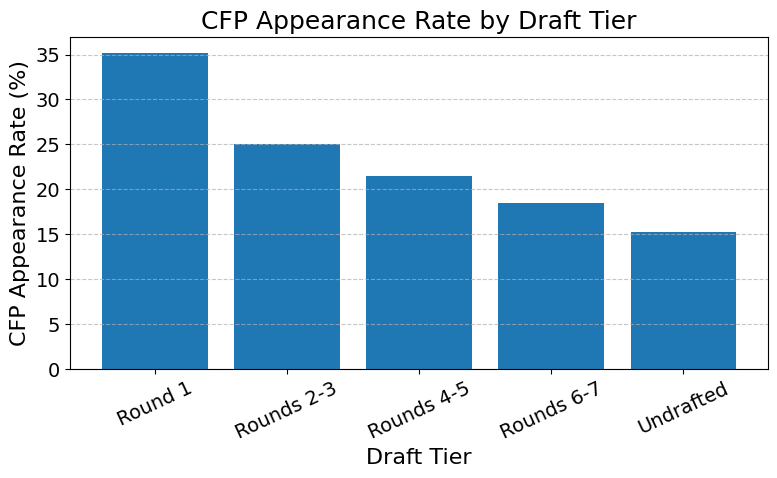

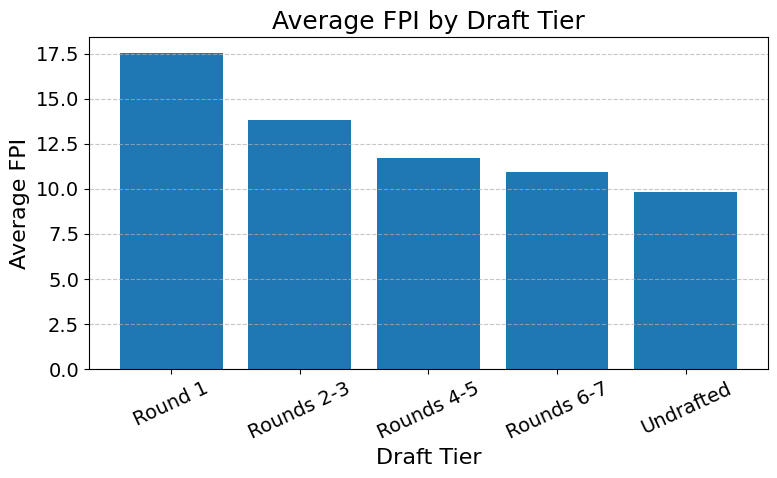

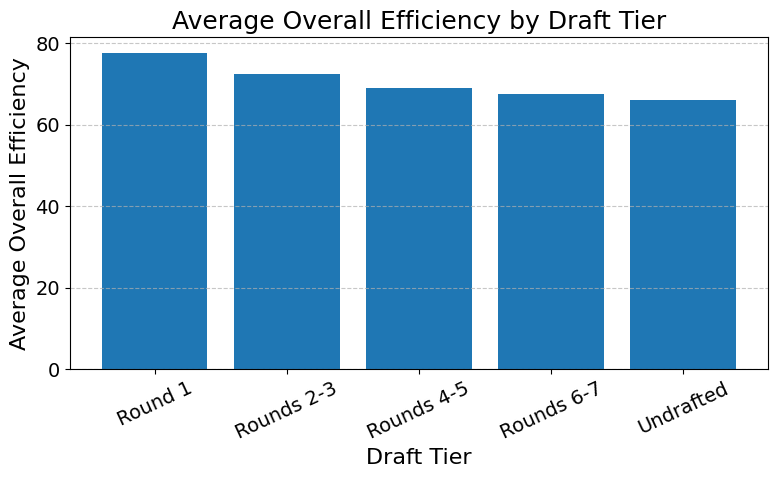

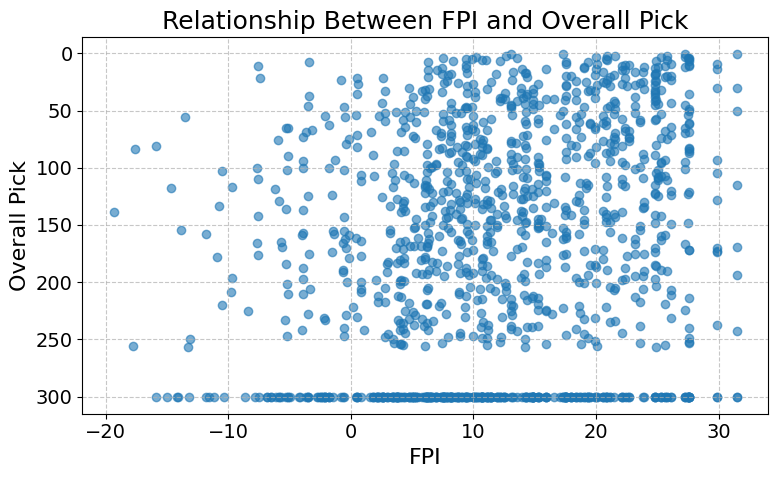

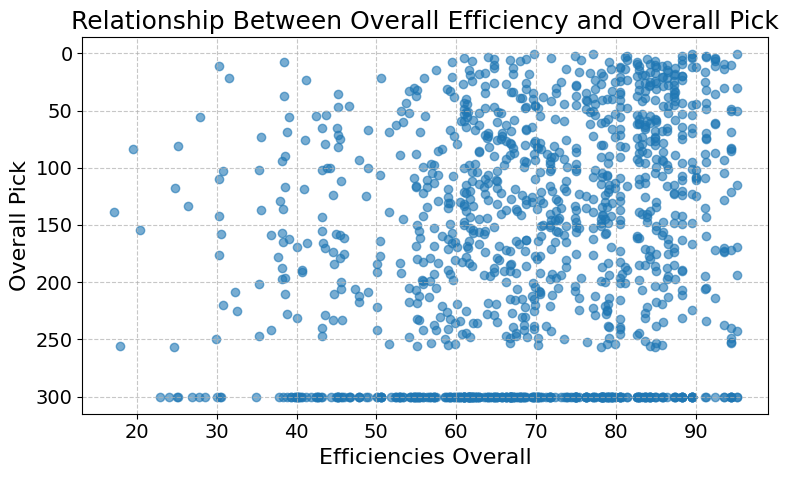

/tmp/ipykernel_6979/2947803108.py:286: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


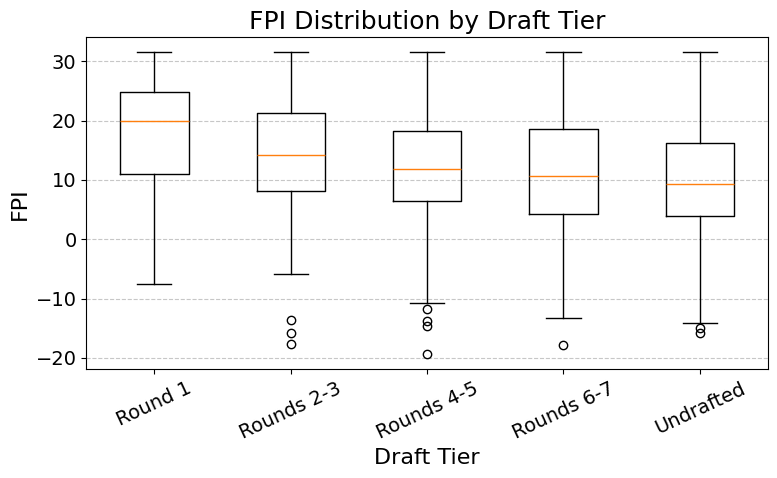

/tmp/ipykernel_6979/2947803108.py:325: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


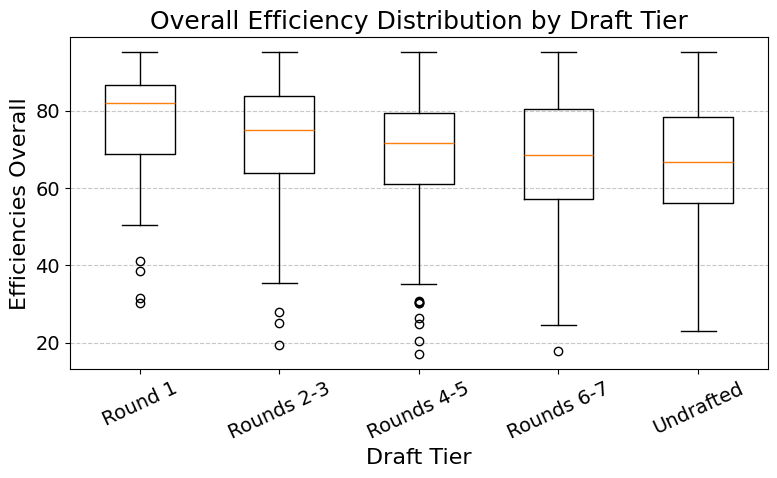


Saved:
CFP_FPI_Efficiency_By_Draft_Tier.csv
CFP_FPI_Efficiency_By_Drafted_Status.csv
CFP_Appearance_Rate_By_Draft_Tier.png
Average_FPI_By_Draft_Tier.png
Average_Efficiency_Overall_By_Draft_Tier.png


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. CREATE DRAFT OUTCOME VARIABLES
# =========================

def draft_tier(pick):
    if pick <= 32:
        return "Round 1"
    elif pick <= 96:
        return "Rounds 2-3"
    elif pick <= 160:
        return "Rounds 4-5"
    elif pick <= 262:
        return "Rounds 6-7"
    else:
        return "Undrafted"

df["Draft Tier"] = df["Overall Pick"].apply(draft_tier)

tier_order = [
    "Round 1",
    "Rounds 2-3",
    "Rounds 4-5",
    "Rounds 6-7",
    "Undrafted"
]

df["Drafted"] = np.where(
    df["Overall Pick"] <= 262,
    "Drafted",
    "Undrafted"
)


# =========================
# 2. SUMMARY TABLE BY DRAFT TIER
# =========================

summary_by_tier = (
    df.groupby("Draft Tier")
    .agg(
        Players=("Player", "count"),
        CFP_Appearance_Rate=("CFP Appearance", "mean"),
        Average_FPI=("FPI", "mean"),
        Median_FPI=("FPI", "median"),
        Average_Efficiency_Overall=("Efficiencies Overall", "mean"),
        Median_Efficiency_Overall=("Efficiencies Overall", "median")
    )
    .reindex(tier_order)
)

summary_by_tier["CFP_Appearance_Rate"] = (
    summary_by_tier["CFP_Appearance_Rate"] * 100
)

summary_by_tier = summary_by_tier.round(3)

print("\n" + "=" * 90)
print("CFP, FPI, AND OVERALL EFFICIENCY BY DRAFT TIER")
print("=" * 90)

print(summary_by_tier)

summary_by_tier.to_csv(
    "CFP_FPI_Efficiency_By_Draft_Tier.csv"
)


# =========================
# 3. SUMMARY TABLE BY DRAFTED STATUS
# =========================

summary_by_status = (
    df.groupby("Drafted")
    .agg(
        Players=("Player", "count"),
        CFP_Appearance_Rate=("CFP Appearance", "mean"),
        Average_FPI=("FPI", "mean"),
        Median_FPI=("FPI", "median"),
        Average_Efficiency_Overall=("Efficiencies Overall", "mean"),
        Median_Efficiency_Overall=("Efficiencies Overall", "median")
    )
)

summary_by_status["CFP_Appearance_Rate"] = (
    summary_by_status["CFP_Appearance_Rate"] * 100
)

summary_by_status = summary_by_status.round(3)

print("\n" + "=" * 90)
print("CFP, FPI, AND OVERALL EFFICIENCY BY DRAFTED STATUS")
print("=" * 90)

print(summary_by_status)

summary_by_status.to_csv(
    "CFP_FPI_Efficiency_By_Drafted_Status.csv"
)


# =========================
# 4. BAR CHART: CFP APPEARANCE RATE BY DRAFT TIER
# =========================

plt.figure(figsize=(8, 5))

plt.bar(
    summary_by_tier.index,
    summary_by_tier["CFP_Appearance_Rate"]
)

plt.title("CFP Appearance Rate by Draft Tier")
plt.xlabel("Draft Tier")
plt.ylabel("CFP Appearance Rate (%)")

plt.xticks(rotation=25)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "CFP_Appearance_Rate_By_Draft_Tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 5. BAR CHART: AVERAGE FPI BY DRAFT TIER
# =========================

plt.figure(figsize=(8, 5))

plt.bar(
    summary_by_tier.index,
    summary_by_tier["Average_FPI"]
)

plt.title("Average FPI by Draft Tier")
plt.xlabel("Draft Tier")
plt.ylabel("Average FPI")

plt.xticks(rotation=25)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "Average_FPI_By_Draft_Tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 6. BAR CHART: AVERAGE OVERALL EFFICIENCY BY DRAFT TIER
# =========================

plt.figure(figsize=(8, 5))

plt.bar(
    summary_by_tier.index,
    summary_by_tier["Average_Efficiency_Overall"]
)

plt.title("Average Overall Efficiency by Draft Tier")
plt.xlabel("Draft Tier")
plt.ylabel("Average Overall Efficiency")

plt.xticks(rotation=25)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "Average_Efficiency_Overall_By_Draft_Tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 7. SCATTER PLOT: FPI VS OVERALL PICK
# =========================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["FPI"],
    df["Overall Pick"],
    alpha=0.6
)

plt.title("Relationship Between FPI and Overall Pick")
plt.xlabel("FPI")
plt.ylabel("Overall Pick")

plt.gca().invert_yaxis()

plt.grid(
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "FPI_vs_Overall_Pick.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 8. SCATTER PLOT: OVERALL EFFICIENCY VS OVERALL PICK
# =========================

plt.figure(figsize=(8, 5))

plt.scatter(
    df["Efficiencies Overall"],
    df["Overall Pick"],
    alpha=0.6
)

plt.title("Relationship Between Overall Efficiency and Overall Pick")
plt.xlabel("Efficiencies Overall")
plt.ylabel("Overall Pick")

plt.gca().invert_yaxis()

plt.grid(
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "Efficiency_Overall_vs_Overall_Pick.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 9. BOXPLOT: FPI BY DRAFT TIER
# =========================

box_data_fpi = [
    df[df["Draft Tier"] == tier]["FPI"].dropna()
    for tier in tier_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    box_data_fpi,
    labels=tier_order
)

plt.title("FPI Distribution by Draft Tier")
plt.xlabel("Draft Tier")
plt.ylabel("FPI")

plt.xticks(rotation=25)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "FPI_Boxplot_By_Draft_Tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 10. BOXPLOT: OVERALL EFFICIENCY BY DRAFT TIER
# =========================

box_data_eff = [
    df[df["Draft Tier"] == tier]["Efficiencies Overall"].dropna()
    for tier in tier_order
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    box_data_eff,
    labels=tier_order
)

plt.title("Overall Efficiency Distribution by Draft Tier")
plt.xlabel("Draft Tier")
plt.ylabel("Efficiencies Overall")

plt.xticks(rotation=25)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "Efficiency_Overall_Boxplot_By_Draft_Tier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# =========================
# 11. SAVE FINAL SUMMARY
# =========================
print("\nSaved:")
print("CFP_FPI_Efficiency_By_Draft_Tier.csv")
print("CFP_FPI_Efficiency_By_Drafted_Status.csv")
print("CFP_Appearance_Rate_By_Draft_Tier.png")
print("Average_FPI_By_Draft_Tier.png")
print("Average_Efficiency_Overall_By_Draft_Tier.png")


Average 40-Yard Dash by Position:
Drafted Status  Drafted  Undrafted  Difference
Position                                      
DL                4.977      5.153       0.176
IOL               5.112      5.263       0.152
SAF               4.402      4.532       0.130
OT                5.083      5.189       0.106
EDGE              4.672      4.773       0.102
WR                4.450      4.515       0.066
S                 4.494      4.559       0.065
LB                4.563      4.615       0.052
RB                4.489      4.526       0.036
CB                4.455      4.489       0.034
TE                4.720      4.700      -0.020
C                 5.154      5.092      -0.062
QB                5.093      4.715      -0.378


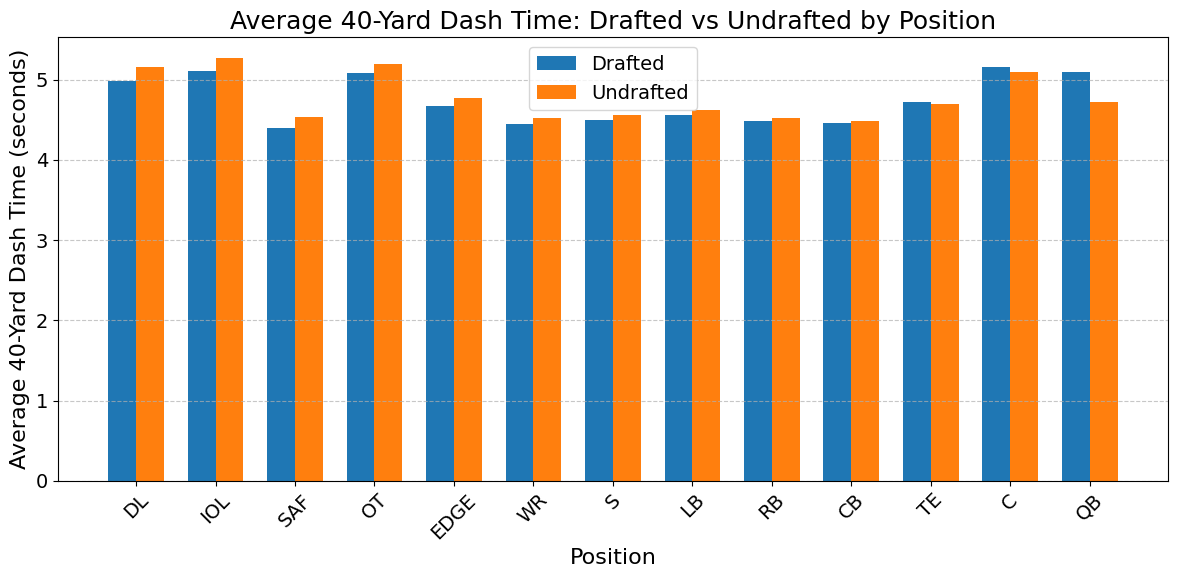

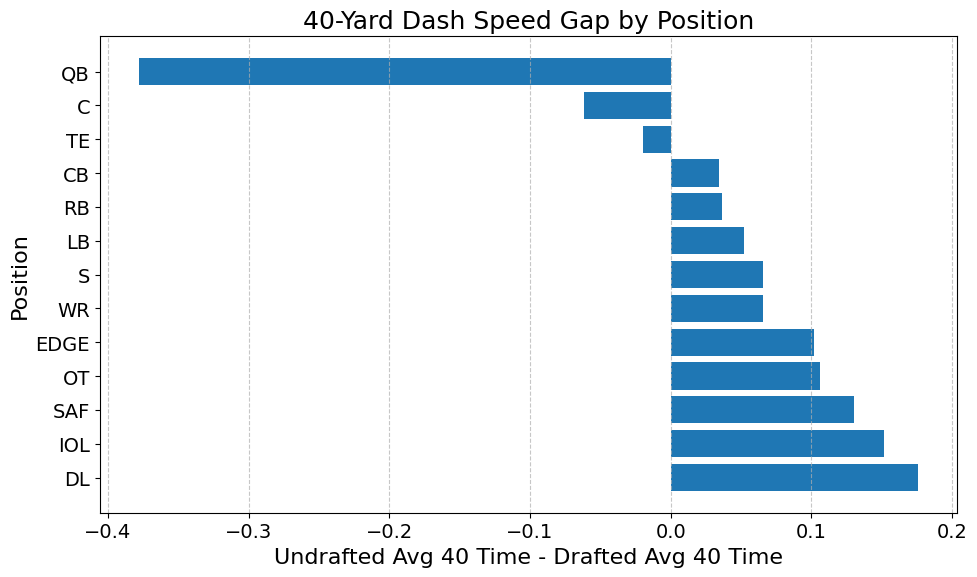


Saved:
Average_40_Drafted_vs_Undrafted_By_Position.csv
Average_40_Drafted_vs_Undrafted_By_Position.png
40_Yard_Dash_Speed_Gap_By_Position.png


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 40-YARD DASH BY POSITION:
# DRAFTED VS UNDRAFTED
# =========================

df["Drafted Status"] = np.where(
    df["Overall Pick"] <= 262,
    "Drafted",
    "Undrafted"
)

# Keep only players with a 40-yard dash time
forty_df = df.dropna(
    subset=["40-Yard Dash (seconds)"]
).copy()

# =========================
# SUMMARY TABLE
# =========================

forty_summary = (
    forty_df
    .groupby(["Position", "Drafted Status"])
    .agg(
        Players=("Player", "count"),
        Average_40=("40-Yard Dash (seconds)", "mean"),
        Median_40=("40-Yard Dash (seconds)", "median")
    )
    .reset_index()
)

# Only keep positions with both drafted and undrafted players
valid_positions = (
    forty_summary
    .pivot(index="Position", columns="Drafted Status", values="Players")
    .dropna()
)

valid_positions = valid_positions[
    (valid_positions["Drafted"] >= 5) &
    (valid_positions["Undrafted"] >= 5)
].index.tolist()

forty_summary = forty_summary[
    forty_summary["Position"].isin(valid_positions)
].copy()

forty_pivot = forty_summary.pivot(
    index="Position",
    columns="Drafted Status",
    values="Average_40"
)

forty_pivot["Difference"] = (
    forty_pivot["Undrafted"] - forty_pivot["Drafted"]
)

forty_pivot = forty_pivot.sort_values(
    by="Difference",
    ascending=False
)

print("\nAverage 40-Yard Dash by Position:")
print(forty_pivot.round(3))

forty_pivot.to_csv(
    "Average_40_Drafted_vs_Undrafted_By_Position.csv"
)

# =========================
# GROUPED BAR CHART
# =========================

positions = forty_pivot.index.tolist()
x = np.arange(len(positions))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    forty_pivot["Drafted"],
    width,
    label="Drafted"
)

plt.bar(
    x + width / 2,
    forty_pivot["Undrafted"],
    width,
    label="Undrafted"
)

plt.xticks(
    x,
    positions,
    rotation=45
)

plt.ylabel("Average 40-Yard Dash Time (seconds)")
plt.xlabel("Position")
plt.title("Average 40-Yard Dash Time: Drafted vs Undrafted by Position")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "Average_40_Drafted_vs_Undrafted_By_Position.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# =========================
# DIFFERENCE CHART
# Positive = drafted players were faster
# =========================

plt.figure(figsize=(10, 6))

plt.barh(
    forty_pivot.index,
    forty_pivot["Difference"]
)

plt.xlabel("Undrafted Avg 40 Time - Drafted Avg 40 Time")
plt.ylabel("Position")
plt.title("40-Yard Dash Speed Gap by Position")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    "40_Yard_Dash_Speed_Gap_By_Position.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved:")
print("Average_40_Drafted_vs_Undrafted_By_Position.csv")
print("Average_40_Drafted_vs_Undrafted_By_Position.png")
print("40_Yard_Dash_Speed_Gap_By_Position.png")

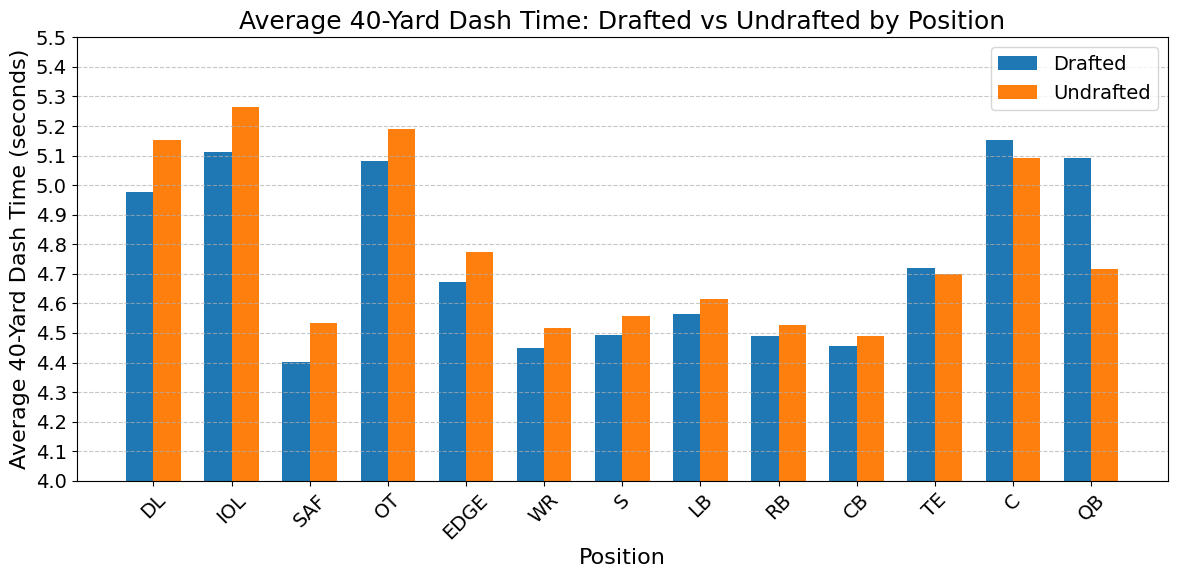

In [61]:
# =========================
# GROUPED BAR CHART
# =========================

positions = forty_pivot.index.tolist()
x = np.arange(len(positions))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    x - width / 2,
    forty_pivot["Drafted"],
    width,
    label="Drafted"
)

plt.bar(
    x + width / 2,
    forty_pivot["Undrafted"],
    width,
    label="Undrafted"
)

plt.xticks(
    x,
    positions,
    rotation=45
)

plt.ylabel("Average 40-Yard Dash Time (seconds)")
plt.xlabel("Position")
plt.title("Average 40-Yard Dash Time: Drafted vs Undrafted by Position")

# Start at 4.0 seconds
plt.ylim(4.0, 5.5)

# More granular ticks
plt.yticks(
    np.arange(4.0, 5.51, 0.1)
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "Average_40_Drafted_vs_Undrafted_By_Position.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [62]:
pip install statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 37.4 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [statsmodels] [statsmodels]

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [63]:
import os
print(os.listdir())

['overall_gains_chart_output_no_log_rank.csv', 'Drafted_vs_Undrafted_By_Position_Heatmap.png', 'Drafted_vs_Undrafted_Differences.png', 'gains_chart_Round_1.csv', '2026_feature_engineered_model_summary.csv', 'BSANStat_cleaned_fixed.ipynb', 'Position_Metric_Differences.png', 'Average_Efficiency_Overall_By_Draft_Tier.png', 'Efficiency_Overall_Boxplot_By_Draft_Tier.png', 'gains_chart_Round_4.csv', 'Drafted_vs_Undrafted_Mean_Comparison.csv', '2026_undrafted_gains_chart_data.csv', '2026_improved_5_tier_coefficients.csv', 'reduced_features_gains_chart_output.csv', '2026_improved_ordinal_predictions.csv', 'Position_Group_Breakdown.csv', 'gains_chart_Round_3_no_log_rank.csv', 'All Matches.csv', 'xgboost_overall_predictions_no_log_rank.csv', 'CFP_Appearance_Rate_By_Draft_Tier.png', '2026_feature_engineered_coefficients.csv', '2026_model_comparison_alpha_and_season_tests.csv', '2026_best_standard_ordinal_predictions.csv', 'Draft_Rate_By_Conference.png', '2026_out_of_sample_ordinal_predictions_enh

In [64]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Methods Sheet.csv"
df = pd.read_csv(file_path)

# =========================
# 2. SELECT NUMERIC VARIABLES
# =========================

X = df.select_dtypes(include=[np.number]).copy()

columns_to_drop = [
    "Season",
    "Log Rank",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams"
]

X = X.drop(columns=[col for col in columns_to_drop if col in X.columns])

# Remove missing values
X = X.dropna()

print("Variables being tested:")
print(list(X.columns))

# =========================
# 3. VIF FUNCTION
# =========================

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Variable"] = data.columns
    vif_df["VIF"] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    return vif_df.sort_values(by="VIF", ascending=False)

# =========================
# 4. CALCULATE VIFS
# =========================

print("\nVIF RESULTS")
vif_results = calculate_vif(X)
print(vif_results)

Variables being tested:
['Height (inches)', 'Weight(lbs)', 'Hand (inches)', 'Arm (inches)', 'Wingspan (inches)', '40-Yard Dash (seconds)', 'Vertical (inches)', 'Bench (reps)', 'Broad Jump (inches)', '3-Cone (seconds)', 'Shuttle (seconds)', 'Overall Pick', 'Combine Participation', 'ELO', 'FPI', 'Efficiencies Overall', 'CFP Appearance', 'National Award']

VIF RESULTS


                  Variable          VIF
3             Arm (inches)  1084.754005
0          Height (inches)   927.913054
4        Wingspan (inches)   552.557947
13                     ELO   501.156061
15    Efficiencies Overall   369.418248
2            Hand (inches)   363.770718
8      Broad Jump (inches)   261.491511
5   40-Yard Dash (seconds)   183.078622
10       Shuttle (seconds)   129.888094
1              Weight(lbs)   117.089923
6        Vertical (inches)    79.775504
9         3-Cone (seconds)    64.255441
14                     FPI    57.557223
7             Bench (reps)    10.670891
12   Combine Participation     5.096498
11            Overall Pick     4.758962
16          CFP Appearance     1.846985
17          National Award     1.344107


In [65]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Methods Sheet.csv"
df = pd.read_csv(file_path)

# =========================
# 2. SELECT NUMERIC VARIABLES
# =========================

X = df.select_dtypes(include=[np.number]).copy()

columns_to_drop = [
    "Season",
    "Log Rank",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams",
    "Arm (inches)",
    "ELO",
    "Overall Pick"
]

X = X.drop(columns=[col for col in columns_to_drop if col in X.columns])

# Remove missing values
X = X.dropna()

print("Variables being tested:")
print(list(X.columns))

# =========================
# 3. VIF FUNCTION
# =========================

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["Variable"] = data.columns
    vif_df["VIF"] = [
        variance_inflation_factor(data.values, i)
        for i in range(data.shape[1])
    ]
    return vif_df.sort_values(by="VIF", ascending=False)

# =========================
# 4. CALCULATE VIFS
# =========================

print("\nVIF RESULTS")
vif_results = calculate_vif(X)
print(vif_results)

Variables being tested:
['Height (inches)', 'Weight(lbs)', 'Hand (inches)', 'Wingspan (inches)', '40-Yard Dash (seconds)', 'Vertical (inches)', 'Bench (reps)', 'Broad Jump (inches)', '3-Cone (seconds)', 'Shuttle (seconds)', 'Combine Participation', 'FPI', 'Efficiencies Overall', 'CFP Appearance', 'National Award']

VIF RESULTS
                  Variable         VIF
0          Height (inches)  723.133485
3        Wingspan (inches)  437.561769
12    Efficiencies Overall  346.543954
2            Hand (inches)  336.468654
7      Broad Jump (inches)  249.743412
4   40-Yard Dash (seconds)  179.348754
9        Shuttle (seconds)  128.447948
1              Weight(lbs)  109.184186
5        Vertical (inches)   78.974934
8         3-Cone (seconds)   63.880111
11                     FPI   46.381801
6             Bench (reps)   10.635541
10   Combine Participation    5.033324
13          CFP Appearance    1.792016
14          National Award    1.171752


In [66]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_vif = add_constant(X)

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif_df.sort_values("VIF", ascending=False))

                  Variable          VIF
0                    const  1549.064506
12                     FPI    20.897181
13    Efficiencies Overall    19.746900
2              Weight(lbs)     4.401986
8      Broad Jump (inches)     2.100849
1          Height (inches)     1.746023
6        Vertical (inches)     1.676313
5   40-Yard Dash (seconds)     1.547354
4        Wingspan (inches)     1.451768
14          CFP Appearance     1.416346
3            Hand (inches)     1.377057
7             Bench (reps)     1.314168
9         3-Cone (seconds)     1.274179
10       Shuttle (seconds)     1.216310
15          National Award     1.046660
11   Combine Participation     1.042043


In [67]:
import pandas as pd
import numpy as np

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# =========================
# 1. LOAD DATA
# =========================

file_path = "Post Methods Sheet.csv"
df = pd.read_csv(file_path)

# =========================
# 2. SELECT NUMERIC VARIABLES
# =========================

X = df.select_dtypes(include=[np.number]).copy()

# =========================
# 3. REMOVE VARIABLES
# =========================

columns_to_drop = [
    "Season",
    "Log Rank",
    "Arm (inches)",
    "ELO",
    "Overall Pick",
    "FPI",
    "Efficiencies Offense",
    "Efficiencies Defense",
    "Efficiencies SpecialTeams"
]

X = X.drop(
    columns=[col for col in columns_to_drop if col in X.columns]
)

# Remove missing values
X = X.dropna()

print("Variables being tested:")
print(list(X.columns))

# =========================
# 4. ADD CONSTANT
# =========================

X_vif = add_constant(X)

# =========================
# 5. CALCULATE VIFS
# =========================

vif_df = pd.DataFrame()
vif_df["Variable"] = X_vif.columns
vif_df["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif_df = vif_df.sort_values(
    by="VIF",
    ascending=False
)

# =========================
# 6. DISPLAY RESULTS
# =========================

print("\nVIF RESULTS")
print(vif_df)

Variables being tested:
['Height (inches)', 'Weight(lbs)', 'Hand (inches)', 'Wingspan (inches)', '40-Yard Dash (seconds)', 'Vertical (inches)', 'Bench (reps)', 'Broad Jump (inches)', '3-Cone (seconds)', 'Shuttle (seconds)', 'Combine Participation', 'Efficiencies Overall', 'CFP Appearance', 'National Award']

VIF RESULTS
                  Variable          VIF
0                    const  1337.601083
2              Weight(lbs)     4.391720
8      Broad Jump (inches)     2.100563
1          Height (inches)     1.745783
6        Vertical (inches)     1.676043
5   40-Yard Dash (seconds)     1.547236
4        Wingspan (inches)     1.450787
3            Hand (inches)     1.375244
12    Efficiencies Overall     1.335708
13          CFP Appearance     1.321479
7             Bench (reps)     1.307659
9         3-Cone (seconds)     1.274088
10       Shuttle (seconds)     1.215677
14          National Award     1.045602
11   Combine Participation     1.035443
